---
title: Task-structure preferences
author:
  - name: Alex Lepauvre
    orcid: 0000-0002-4191-1578
    corresponding: true
    email: alex_francois.lepauvre@tu-dresden.de
    roles: [conceptualization, data curation, formal analysis, investigation, methodology, project administration, software, validation, visualization, writing - original draft, writing - review & editing]
    affiliations:
      - name: TUD Dresden University of Technology
        address: Dresden 01187
        country: DE
        department: Chair of Cognitive Computational Neuroscience, Faculty of Psychology
        ror: https://ror.org/042aqky30
  - name: Florian Ott
    orcid: 0000-0002-6183-600X
    corresponding: false
    roles: [funding acquisition, investigation, writing - review & editing]
    affiliations:
      - name: TUD Dresden University of Technology
        address: Dresden 01187
        country: DE
        department: Chair of Cognitive Computational Neuroscience, Faculty of Psychology
        ror: https://ror.org/042aqky30
  - name: Stefan Kiebel
    orcid:  0000-0002-5052-1117
    corresponding: false
    roles: [conceptualization, funding acquisition, methodology, resources, supervision, visualization, writing - original draft, writing - review & editing]
    affiliations:
      - name: TUD Dresden University of Technology
        address: Dresden 01187
        country: DE
        department: Chair of Cognitive Computational Neuroscience, Faculty of Psychology
        ror: https://ror.org/042aqky30
keywords:
  - Decision making
  - Reinforcement learning
abstract: |
  []
date: last-modified
number-sections: true
bibliography: references.bib
---

## Introduction

A central idea in Bayesian accounts of perception and sensorimotor control is that the brain does not rely on current sensory evidence alone [@knill2004bayesian;@lee2003hierarchical;@rao1999predictive;@clark2013whatever;@friston2010free] because sensory evidence is often noisy, incomplete, or costly to acquire with high precision. Prior information can reduce this uncertainty by providing an efficient summary of regularities learned from experience and from the statistical structure of the environment. The Bayesian solution is therefore to combine current evidence with prior information. As formulated in the ‘Bayesian brain hypothesis’, the influence of prior information should depend on uncertainty: when current evidence is unreliable, behavior should rely more strongly on the prior. Conversely, when current evidence is reliable, it should dominate behavior. For example, @kording2004bayesian provided a canonical demonstration of this principle, showing that participants combine learned priors with sensory feedback according to their relative uncertainty. 

A similar logic may apply to planning-based decision making. In this case, the role of sensory evidence is taken by an internally generated estimate of action value. In sequential decision tasks, such estimates are assumed to be generated by internal forward planning, which provides state-specific information about the long-value of choosing an action. However, generating these estimates is assumed to be computationally costly because it requires evaluating future outcomes in complex and dynamic environments. In analogy to the Bayesian view on perception, agents may therefore combine their evidence, i.e. their internal estimates, with stored prior information about which actions are usually appropriate in a given task. In this view, action selection reflects a balance between a costly state-specific estimate and a stored prior tendency to act in a particular way. This idea has been applied previously in a Bayesian account of the balance between habitual and goal-directed control, in which habitual tendencies were modelled as priors over policies that are balanced against goal-directed information about current outcome contingencies [@schwobel2021balancing;@schwobel2024joint]. This approach also resonates with resource-rational accounts of planning, which postulates that the brain adapts its planning computations to the costs and benefits of using its relatively limited cognitive resources [@gershman2015computational;@lai2021policy;@lai2024human]. 

Building on Bayesian accounts of prior–evidence integration and resource-rational accounts of costly planning, we assume that choices in complex sequential decision making reflect the integration of two sources of information about action. First, participants have acquired, for example during training, task-structured preferences that reflect regularities in the task structure and their own experience within the task. Second, as is typically modelled in reinforcement learning, for each trial, participants use forward planning to derive values for each available action in an online fashion. Assuming a Bayesian approach, we hypothesize that these two sources are integrated by weighting the contribution of planning against preferences by their respective uncertainties. This hypothesis implies that on trials with strong preferences, these should guide choices and produce faster responses because less planning is needed. On trials with weak or uncertain preferences, decision making should be more weighted towards forward planning and consequently, response times should be increased due to the increase in computations. 

In this paper, we test this hypothesis in a complex sequential decision-making task, using choice model comparisons and response-time analyses. Specifically, we use optimal forward planning as a benchmark and ask whether participants’ deviations from this benchmark are systematic and better explained by task-structured preferences. We compare against several alternative models of how participants may combine planning-derived decision values with potential preferences. Our results show that participants’ choices are best captured by a model that combines planning-derived decision values with state-dependent preferences constructed from multiple task features. We further show in additional analyses that these preferences interact with planning such that choices are guided more strongly by planning when preferences are weak, and more strongly by preferences when they are decisive. Together, these findings suggest that, in complex sequential decision problems, costly forward planning is integrated with structured, task-informed preferences that enable faster and less computationally demanding choices when they provide a clear action tendency. 

In [1]:
# Import all packages

# General utilities:
import os 
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Stats
import pymc as pm
import arviz as az
import bambi as bmb
from scipy.special import logit, expit
from scipy.stats import pearsonr

# Custom packages:
from stabst.MarkovDecisionProcess import MDP
from stabst.TaskConfig import LimitedEnergyTask
from stabst.utils import avg_reduce_mdp, abstract2ground_value

A4_inches = [8.27-0.5,11.69-0.5]

def make_grid(dv_min, dv_max, pref_min, pref_max):
    """
    Makes a 2D grid reflecting the limits of our modelled variables (preferences and DV)
    Parameters
    ----------
    dv_min : _type_
        _description_
    dv_max : _type_
        _description_
    pref_min : _type_
        _description_
    pref_max : _type_
        _description_

    Returns
    -------
    _type_
        _description_
    """
    x1_grid = np.linspace(start=dv_min, stop=dv_max, num=300)
    x2_grid = np.linspace(start=pref_min, stop=pref_max, num=300)
    x1_mesh, x2_mesh = np.meshgrid(x1_grid, x2_grid)
    x_grid = np.stack(arrays=[x1_mesh.flatten(), x2_mesh.flatten()], axis=1)
    return x1_grid, x2_grid, x_grid

# Define custom functions:
# Choice behaviour model with preferences and DV:
def preference_model(
        y: np.array,
        decision_values: np.array,
        pref_regressors: pd.DataFrame,
        subject_index: np.array,
        subject_labels: np.array      
):
    '''
    Parameters
    ----------
    y : np.array [N samples, ]
        Observed binary data (1, 0...)
    decision_values : np.array [N samples, ]
        DV to regress onto the observed data
    pref_regressors : np.array [N samples, M regressors]
        Regressor to fit participants preference for. We can have M regressors
    subject_index : np.array  [N samples, ]
        Index of the subject associated with each observation
    subject_labels : np.array  [N subjects, ]
        Single identifier of each subject
    coords : dict  
        "subject": subj_labels, 
        "coef": ["intercept", "slope"],
        The subject maps the data to each subject, the coef are for the coefficients
    b_prior_mean : Optional[float], optional
        Prior mean of each beta parameters, by default 0
    b_prior_sigma : Optional[float], optional
        Prior variance of the population level distribution of the beta, by default 2`
    s_prior_sigma : Optional[float], optional
        Prior between subjects variance, by default 2
    n_drawss : Optional[int], optional
        Number of draws for the posterior, by default 1000
    n_tuning_draws : Optional[int], optional
        Number of tuning draws, by default 1000
    Returns
    -------
    tuple[pm.Model, arviz.InferenceData]
        pm.model : pymc model object
        idata : arviz inference data
    '''
    # Get dimensions:
    n_obs = y.shape[0]
    n_groups = subject_labels.shape[0]
    n_pref = pref_regressors.shape[1]

    # Create intercept:
    intercept = np.ones(n_obs)

    # Set coordinates:
    coords = {
        "subject": subject_labels,
        "coef_intercept": ["B_intercept"],
        "coef_planning": ["B_plan"],
        "coef_pref": ["B_" + col for col in pref_regressors.columns],
        "coef_interaction": ["slope"],
    }


    # Model:
    with pm.Model(coords=coords) as planning_preferences_interaction_model:
        # Data:
        y_obs = pm.Data("y_obs", y)
        intercept = pm.Data("intercept", intercept)
        planning = pm.Data("planning", decision_values)
        preferences = pm.Data("preferences", pref_regressors)
        subj_idx = pm.Data("subj_idx", subject_index.astype("int32"))

        # Hyperpriors:
        # Intercept term
        beta_intercept = pm.Normal("beta_intercept", mu=0, sigma=2, dims="coef_intercept")
        sigma_intercept = pm.HalfNormal("sigma_intercept", sigma=2, dims="coef_intercept")
        # Planning term:
        beta_planning = pm.Normal("beta_planning", mu=0, sigma=2, dims="coef_planning")
        sigma_planning = pm.HalfNormal("sigma_planning", sigma=2, dims="coef_planning")
        # Preference terms:
        beta_pref = pm.Normal("beta_pref", mu=0, sigma=2, dims="coef_pref")
        sigma_pref = pm.HalfNormal("sigma_pref", sigma=2, dims="coef_pref")
        # Interaction term:
        beta_interaction = pm.Normal("beta_interaction", mu=0, sigma=2, dims="coef_interaction")
        sigma_interaction = pm.HalfNormal("sigma_interaction", sigma=2, dims="coef_interaction")

        # Offset parameters:
        z_intercept = pm.Normal("z_intercept", 0, 1, dims=("subject", "coef_intercept"))
        z_planning = pm.Normal("z_planning", 0, 1, dims=("subject", "coef_planning"))
        z_biases = pm.Normal("z_biases", 0, 1, dims=("subject", "coef_pref"))
        z_interaction = pm.Normal("z_interaction", 0, 1, dims=("subject", "coef_interaction"))

        # Centered parameters:
        beta_intercept_sub = pm.Deterministic("beta_intercept_sub", beta_intercept + z_intercept * sigma_intercept, 
                                              dims=("subject", "coef_intercept"))
        beta_planning_sub = pm.Deterministic("beta_planning_sub", beta_planning + z_planning * sigma_planning, 
                                             dims=("subject", "coef_planning"))
        beta_pref_sub = pm.Deterministic("beta_pref_sub", beta_pref + z_biases * sigma_pref, 
                                         dims=("subject", "coef_pref"))
        beta_interaction_sub = pm.Deterministic("beta_interaction_sub", beta_interaction + z_interaction * sigma_interaction, 
                                                dims=("subject", "coef_interaction"))
        
        # Estimate the score of the bias (i.e. weighted sum of each of the biases regressors):
        preference = pm.Deterministic('preference', (beta_pref_sub[subj_idx] * preferences).sum(axis=-1))
        
        # Convert the bias back onto probability space:
        pi_prior = pm.Deterministic("pi_prior", pm.math.sigmoid(preference))

        # Compute the normalized entropy (defined between 0 and 1):
        max_entropy = -0.5 * np.log(0.5) - (1-0.5) * np.log(1 - 0.5)
        entropy = pm.Deterministic("entropy", (-pi_prior * pm.math.log(pi_prior) - (1-pi_prior) * pm.math.log(1 - pi_prior)) / max_entropy)
        # Normalize the entropy to be bett
        
        # Eta parameter is the weighted sum of the intercept, the bias, the planning values and 
        # the interaction between the entropy of the bias and the planning
        eta = (
            beta_intercept_sub[subj_idx, 0] * intercept
            + preference
            + beta_planning_sub[subj_idx, 0] * planning
            + beta_interaction_sub[subj_idx, 0] * (entropy * planning)
        )
        
        # Expected values:
        p = pm.Deterministic("p", pm.math.sigmoid(eta))

        # Likelihood 
        pm.Bernoulli("y", p=p, observed=y_obs)

        # Sampling:
        idata = pm.sample(
            draws=n_samples,
            tune=n_warmup,
            chains=n_chains,
            target_accept=0.85,
            idata_kwargs={"log_likelihood": True},
        )
        # Sample posterior predictive for later model checking:
        idata.extend(pm.sample_posterior_predictive(idata, var_names=["p", "y"]))
    return idata

def linear_decay_mvavg(arr, window_size, init_val = 0.5):
    '''
    Compute the moving average of a 1D array with a specified window size and 
    linear decay
    '''
    # Pad the array with initial value
    arr = np.pad(arr.astype(float), (window_size - 1, 0), constant_values=init_val)
    # Generate kernel:
    kern = np.arange(window_size)/np.sum(np.arange(window_size))
    return np.convolve(arr, kern, mode='valid')

def predict_responses(dv, pref, idata):
    """_summary_

    Parameters
    ----------
    dv : _type_
        _description_
    pref : _type_
        _description_
    beta_plan : _type_
        _description_
    beta_interaction : _type_
        _description_
    """
    # Compute the preferences entropy:
    p_pref = expit(pref)
    entropy = -p_pref * np.log(p_pref) - (1-p_pref) * np.log(1 - p_pref)

    # Stack all posterior samples (chains and draws)
    b_plan = idata.posterior["beta_planning"].stack(sample=("chain", "draw")).values.squeeze()  # shape (n_samples,)
    b_inter = idata.posterior["beta_interaction"].stack(sample=("chain", "draw")).values.squeeze()  # shape (n_samples,)

    # Compute predictions for each sample and input
    eta = b_plan[:, None] * dv + pref + b_inter[:, None] * dv * entropy
    pred = expit(eta)  # shape (n_samples, n_points)

    # Compute mean and 95% credible interval
    mean_pred = np.mean(pred, axis=0)
    lower_95 = np.percentile(pred, 2.5, axis=0)
    upper_95 = np.percentile(pred, 97.5, axis=0)

    return mean_pred, lower_95, upper_95

def truncate_colormap(cmap, min_val=0.0, max_val=1.0, n=256):
    """Slice a colormap to the sub-range [min_val, max_val]."""
    colors = cmap(np.linspace(min_val, max_val, n))
    return mcolors.LinearSegmentedColormap.from_list(
        f"{cmap.name}_trunc({min_val:.2f},{max_val:.2f})", colors
    )

# Set random seed for reproducibility:
np.random.seed(42)
warnings.filterwarnings("ignore")

n_samples = 1000
n_warmup = 1000
n_chains = 4

In [2]:
# Download the data if needed:
if not os.path.exists('./data/raw_data/all_participants_data.csv'):
    if not os.path.exists('./data/raw_data'):
        os.makedirs('./data/raw_data')
    url = 'https://raw.githubusercontent.com/fmott/context_dependent_planning/4d239b721749adabb8fe8f1d8ac2d1ecdeba17cf/data/behaviour/data_all_participants_20220215120148.csv'
    os.system(f'wget {url} -O ./data/raw_data/all_participants_data.csv')
if not os.path.exists('./data/raw_data/all_participants_age_gender.csv'):
    if not os.path.exists('./data/raw_data'):
        os.makedirs('./data/raw_data')
    url = 'https://raw.githubusercontent.com/fmott/context_dependent_planning/4d239b721749adabb8fe8f1d8ac2d1ecdeba17cf/data/behaviour/age_gender.csv'
    os.system(f'wget {url} -O ./data/raw_data/all_participants_age_gender.csv')
# Load the data:
beh_data = pd.read_csv('./data/raw_data/all_participants_data.csv')
demographic_data = pd.read_csv('./data/raw_data/all_participants_age_gender.csv', sep=";")

# Extract demographic information:
n_participants = demographic_data.shape[0]
n_female = demographic_data['gender (m = 1, f = 2)'].value_counts()[2]
mean_age = demographic_data['age'].mean()
std_age = demographic_data['age'].std()

# Calcuate the number of trials rejected & RT in each subject:
n_rej = []
rt = []
n_score = []
for sub in np.unique(beh_data['vpn']):
    # Extract subject's data:
    sub_data = beh_data[beh_data['vpn'] == sub]
    n_na = sub_data.shape[0] - sub_data.dropna().shape[0]
    n_rej.append(n_na)
    rt.append(sub_data.dropna()['reaction_time'].mean())
    n_score.append(sub_data.dropna()['points'].to_numpy()[-1])
# Get average and standard deviation
mean_timeout = np.mean(n_rej)
sd_timeout = np.std(n_rej)
mean_rt = np.mean(rt)
sd_rt = np.std(rt)
mean_points = np.mean(n_score)
sd_points = np.std(n_score)

# ===================================================================
# Data preprocessing:
# Remove nans:
beh_data = beh_data.dropna()
# Remove timeout:
beh_data = beh_data[beh_data["timeout"] == 0]
# Flip responses: 1 = accept:
beh_data["response"] = (beh_data["response"] == 0).astype(int)
# Make trial 1 based
beh_data["trial"] = beh_data["trial"] + 1
# Generate future cost based on the transitions:
transitions_costs = {
    0: [1, 1],
    1: [2, 1],
    2: [1, 2],
    3: [2, 2]
}
beh_data["fc"] = [transitions_costs[row["transition"]][1] for _, row in beh_data.iterrows()]


## Methods

### Data
To test our hypothesis, we reused data from a previously published study by @ott2022forward and colleagues, in which `{python} f"{n_participants:.0f}"` participants (`{python} f"{n_female:.0f}, mean age={mean_age:.1f}, SD={std_age:.1f}"`) took part in a sequential decision making task [@ott2022forward;@ott2022forward-data]. The study was approved by the Institutional Review Board of the Technische Universität Dresden and conducted in accordance to ethical standards of the Declaration of Helsinki.

@fig-design shows a schematic representation of the task. Participants were instructed to gather as many points as possible throughout the task. In each trial, they were presented with an offer associated with a reward of either 1, 2, 3 or 4 points, which they could either accept or reject. To accept the offer in a trial, participants had to pay an energy cost of either 1 or 2 energy points (low cost, LC and high cost, LC respectively). When they rejected the offer, they gained 1 energy point. Participants’ energy level was capped at 6, so their energy could range from 0 (depleted energy) to 6 (max energy). Offers varied in each trial following a uniform distribution (equal probability of each offer in each trial). Costs remained fixed for 4 consecutive trials, which we refer to as a segment (see @fig-design B), and participants were informed of the price of the current segment and the next segment. The costs of the next segment was pseudorandomized to equate the probability of each transition (from current HC or LC to future HC or LC, see @fig-design C) and ensure that each transition occurred 15 times. When participants accepted an offer that they could not afford (current energy level below current cost), no reward was awarded and a warning was displayed. 

![Experimental design: (A) Single trial procedure, each frame represents a step within the trial with duration of each step above. Top row depicts participants accepting, bottom row depicts participants rejecting. In each trial, participants are presented with N golden cups, the number of cups symbolizes the amount of reward. The blue bar represents energy level, they yellow bar represents accumulated reward so far, lightning symbols at the bottom right of each frame represent current cost (left) and future cost (right). (B) Between trial costs dependencies. A segment consists of 4 trials within which cost is fixed, and participants are aware of the cost in the current and future 4 trials but not beyond. (C) Transition structure. Cost can transition from low cost (LC) to high cost (HC), LC to LC, HC to LC and HC to HC. Reproduced from @ott2022forward](images/experimental_design.jpg){#fig-design fig-alt="Experimental design"}

Accordingly, each trial was defined by several task factors: the current offer, the participant’s current energy level, the current cost of accepting, and the cost in the upcoming segment. Participants had to decide whether to accept or reject the offer under the specific combination of these factors. Because accepting depleted energy while rejecting replenished it, each choice also changed the state in which the participant entered subsequent trials. Maximizing overall return was therefore non-trivial and required considering the future consequences of current choices. 

In the beginning of each trial, a fixation cross was presented for 0.5s in the middle of the screen. Then, an offer appeared represented by the number of “cups” presented in the middle of the screen and choice options were presented on each side of the screen, surrounded by a black frame. Participants had 5s to provide an answer, by selecting one or the other options (accept or reject), in which case the frame around the chosen option disappeared. Following their choice, the resulting change in energy and points were displayed (green indicating an increase in point and/or energy, red indicating a decrease in energy) for 1s. The trial ended with an inter-trial interval (ITI) ranging from 2 to 5s (uniformly sampled, rounded to the first decimal) in which the offer disappeared and unframed choice options remained on screen. If participants took longer than 5s to provide their answer, a warning message was displayed and the next trial started. 

To familiarize themselves with the task, participants conducted a training session of 144 trials, corresponding to 36 segments. Participants then conducted the experiment consisting of 240 trials (60 segments). Participants started with an energy budget of 3, and their reward points were accumulated throughout the entire experiment. Trial sequence was pseudorandomized, such that each costs transitions (LC to LC, LC to HC, HC to LC and HC to HC, see @fig-design C) occurred equally often within the training and test sessions, resulting in 9 repetition of each transition in the training session and 15 in the experiment. In addition, the offer were sampled to be equally distributed within each transition. The sequence of costs transitions and offers was kept the same across participants. Participants were offered two to three minutes breaks inside the scanner every 20 segments. The test sessions lasted around 40min. 

### Forward planning component
To model optimal behaviour in the task, we operationalized our task as a Markov Decision Process (MDP) with the following tuples:

$$
MDP = (S, A, P, R)
$$

Where $S$ represents all possible states in our task, where each state $s$ consists of a combination of the experimental variables in our task:  $S=E \times O \times CC \times FC \times T$, with energy $E={0, 1, ..., 6}$, offer $O={1, 2, 3, 4}$, current segment cost $CC={1, 2}$, future segment cost $FC={1, 2}$ and trial $T={1, 2,..., 13}$. Time steps (i.e. trials) had to be incorporated in the state space to account for the cost being trial dependent. $A$ is the set of possible actions in our task ($accept=1, reject=0$), $P$ is the transitional probability from a given state to all other states ($P=P_{\forall s \in S}(s'|s, a)$), and $R$ is the reward function characterizing the reward participants can obtain in a given state for each action ($R=R_{\forall s \in S}(s|a)$).

While optimal behaviour would require considering outcomes up until the end of the task, we modelled planning over a limited horizon, following the approach used by @ott2022forward. Participants had explicit information about the current and upcoming segment, corresponding to an eight-trial horizon. Solving the task only over these eight trials would implicitly treat the task as ending after the upcoming segment, leading the optimal policy to spend all remaining energy by the end of that horizon. To avoid this terminal artefact, we included one additional segment beyond the instructed horizon. Thus, action values were computed over a twelve-trial planning horizon, with a terminal value set after the twelfth trial, yielding 13 time points in the dynamic-programming solution. In the first 8 trials, the probability of the next state reflects the offer-related stochasticity, while costs are known. For trials beyond the known horizon, the uncertainty associated with the offer is compounded by the uncertainty related to the next cost transition [see @ott2022forward for more details]. 

We applied backward induction to compute the long-term value associated with each action in any given state [i.e. the $Q$ function @sutton1998reinforcement]. Participants maximizing return should choose the action with the largest value. As there were only two possible actions in our task (accept or reject), we computed decision values (DV) as: 

$$
DV_s = Q(s, a=1) - Q(s, a=0)
$$

In states where the DV are negative, participants should reject, and in states where DV are positive, participants should accept the offer. 

In [3]:
# ===================================================================
# Task MDP:
# Create the task and its parameters (transition probability, reward...):
task = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4)
task.build()

# Create full MDP and compute solution for later reference:
gamma = 1
task_mdp = MDP(task.states, task.tp, task.r, gamma, s2i=task.s2i)
V_full, Q_full = task_mdp.backward_induction()

# Add DV to the data frame:
dv = Q_full[:, 1] - Q_full[:, 0]
# Loop through each trial to set DV:
dv_trials = []
for trial_i, trial in beh_data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    fc = transitions_costs[trial.transition][1]
    dv_trials.append(dv[task.s2i[(e, o, cc, fc, t)]])
beh_data['dv'] = dv_trials
# Compute offer specific decision value regressors:
beh_data['dv_23'] = beh_data['dv'].to_numpy() * (beh_data['is_2'].to_numpy() + beh_data['is_3'].to_numpy())
beh_data['dv_14'] = beh_data['dv'].to_numpy() * (beh_data['is_1'].to_numpy() + beh_data['is_4'].to_numpy())

### Modelling of participants responses

Participants behaviour were modeled using a logistic regression: 
$$
P(a=1) = \frac{1}{1+e^{-\eta}}
$$ {#eq-logistic_reg}

We specified four models that differed in how the linear predictor $\eta$ was specified. All models included planning-derived DV, but differed in the additional regressors used to explain systematic deviations from optimal planning. We describe these models in the following, starting with the pure planning model as a benchmark and then adding increasingly structured accounts of participants’ deviations from optimal planning.

#### Planning model
To test whether there is any systematicity in participants deviations from optimality, we first specified a pure planning model, in which participants responses is modeled as a function of DV only: 

$$
\begin{aligned}
\eta_{planning} &= \beta_{plan} \times DV
\end{aligned}
$$ {#eq-planning-model}

This model acted as a benchmark. If the suboptimality (i.e. deviations from forward planning only) in participants responses reflects unstructured noise, alternative models with additional regressors would only increase model complexity but not accuracy. 

#### Frequency prior model

Alternatively, participants deviations from optimality might reflect a recency bias, whereby participants choice on a given trial is biased towards the most frequent action in recent history. Recent accounts of planning consider that priors consist of a state independent recency bias [@schwobel2021balancing;@schwobel2024joint;@kuperwajs2021planning]. Similarly, under the policy compression framework, the optimal policy integrates planning and marginal action probability across states [@lai2021policy;@lai2024human]. To test whether in our task participants responses are biased towards most frequent action taken in previous trials, and approximate the policy compression framework, we fitted a **frequency model**, which models participants responses as a function of DV combined with a recency bias: 

$$
\begin{aligned}
\eta_{frequency} =& \beta{plan} \times DV + \beta{prior} \times P(A)
\end{aligned}
$$ {#eq-frequency-model}

We computed $P(A)_t$ in each trial $t$ using a linearly decaying moving average going back $k=20$ trials, assuming temporally discounted effects of past actions (see Supplementary 1 for exploration of the fit at different $k$):

$$
\begin{aligned}
P(A)_t =& \frac{\sum_{i=t-k}^{t-1}x_i \times w_i}{\sum_{i=t-k}^{t-1}w_i}
\end{aligned}
$$ {#eq-mvavg}
And $w=[1, 2, ..., k]$

#### Context model

In addition, we used the best-fitting model (among 21 models) from @ott2022forward, to test whether participants treat groups of states as separate contexts in which they plan to different extents.  We refer to this model as the **context model**. Here, the planning component (DV) is split between extreme and intermediate offers (offers [1, 4] and [2, 3] respectively) to reflect the fact that participants treat those as separate contexts, with different control requirements. In addition, the model comprise offer specific and energy related flexible biases regressors: 

$$
\begin{aligned}
\eta_{context} =& \beta{plan23} \times DV_{23} + \beta{plan14} \times DV_{14} + \\
&\beta_{O1}\mathbf{I}_{O1} + \beta_{O2}\mathbf{I}_{O2} + \beta_{O3}\mathbf{I}_{O3} + \beta_{O4}\mathbf{I}_{O4} + \\
&\beta_{basic}\mathbf{I}_{basic} + \beta_{maxE}\mathbf{I}_{maxE} + \\
&\beta_{minE_{LC}}\mathbf{I}_{minE_{LC}} + \beta_{minE_{HC}}\mathbf{I}_{minE_{HC}} 
\end{aligned}
$$ {#eq-context-model}

$\mathbf{I}$ indicate dummy regressors encoding specific experimental conditions: $\mathbf{I}_{basic}$ encodes trials where energy is sufficient to accept the offer and inferior to 6, $\mathbf{I}_{maxE}$ encodes trials where energy is equal to 6, $\mathbf{I}_{minE_{LC}}$ for trials where energy is too low to accept the offer when cost is low,  $\mathbf{I}_{minE_{HC}}$ for trials where energy is too low to accept the offer when cost is high, $\mathbf{I}_{O1-4}$ for trials with offer 1-4 where energy is sufficient to accept. 

#### Preferences model

Finally, we specified a preference model to test whether participants’ choices reflect the integration of forward planning with task-structured preferences. The model contains three components. First, as in the planning model, choices depend on the planning-derived decision value. Second, choices depend on a state-dependent preference score. This preference score is constructed by assigning weights to the levels of the main task features, namely offer, energy, current cost, and future cost, and linearly combining the corresponding weights for the current state. Third, the model includes a modulation term that tests whether the influence of planning depends on the uncertainty of the preference score. We quantified this uncertainty as the entropy of the preference-derived action tendency. The model therefore tests the prediction that participants rely more strongly on planning when their preferences are weak or uncertain: 

$$
\begin{aligned}
\eta_{pref} &= \beta_{plan} \times DV + pref + \beta_{modulation} \times(H(Preferprefences) \times DV)
\end{aligned}
$$ {#eq-preference_model}

Where:
$$
\begin{aligned}
pref = \mathbf{X_{pref}}\mathbf{\beta}
\end{aligned}
$$

And $H(pref)$ is the entropy of the preference score:

$$
\begin{aligned}
H(pref) = -\sigma(pref) * log(\sigma(pref)) - (1-\sigma(pref)) * log(1-\sigma(pref))
\end{aligned}
$$ {#eq-entropy}

With:

$$
\begin{aligned}
\sigma(x) = \frac{1}{1+e^{-x}}
\end{aligned}
$$ {#eq-entropy}

Participants features dependent preferences are estimated as latent variables. $\mathbf{X_{pref}}$ is a $[M \times N]$ (M=measurements, N=experimental levels) matrix dummy coding each factors of the experimental setup (energy, offer, current and future costs), and $\mathbf{\beta}$ is a vector of weights estimated for each level of each factor.

In [4]:
# Preparing regressors:
# Compute categorical regressors that should be somewhat similar to our priors:
# Categorical offer regressor for high and low offer
beh_data['is_12'] = beh_data['is_1'].to_numpy() + beh_data['is_2'].to_numpy()
beh_data['is_34'] = beh_data['is_3'].to_numpy() + beh_data['is_4'].to_numpy()
# Continuous regressor for high and low offer:
beh_data['high_vs_low'] = beh_data['is_34'] - beh_data['is_12']

# Categorical costs regressor
beh_data['is_lc'] = (beh_data['energy_cost'] == 1).astype(int).to_numpy()
beh_data['is_hc'] = (beh_data['energy_cost'] == 2).astype(int).to_numpy()
# Categorical future costs regressor
beh_data['is_lfc'] = (beh_data['fc'] == 1).astype(int).to_numpy()
beh_data['is_hfc'] = (beh_data['fc'] == 2).astype(int).to_numpy()

# Categorical transition regressor
beh_data['is_trans1'] = (beh_data['transition'] == 0).to_numpy()
beh_data['is_trans2'] = (beh_data['transition'] == 1).to_numpy()
beh_data['is_trans3'] = (beh_data['transition'] == 2).to_numpy()
beh_data['is_trans4'] = (beh_data['transition'] == 3).to_numpy()

# Categorical energy regressor:
beh_data['e_is_0'] = (beh_data['energy'] == 0).to_numpy()
beh_data['e_is_1'] = (beh_data['energy'] == 1).to_numpy()
beh_data['e_is_2'] = (beh_data['energy'] == 2).to_numpy()
beh_data['e_is_3'] = (beh_data['energy'] == 3).to_numpy()
beh_data['e_is_4'] = (beh_data['energy'] == 4).to_numpy()
beh_data['e_is_5'] = (beh_data['energy'] == 5).to_numpy()
beh_data['e_is_6'] = (beh_data['energy'] == 6).to_numpy()

# Random effects
subj_idx_raw, subj_labels = pd.factorize(beh_data["vpn"])

### Model fitting and comparison

Models were fitted to participants’ response data as Bayesian hierarchical logistic regressions using PYMC [@abril2023pymc] and Bambi [@Capretto2022]. We excluded trials where participants did not provide a response or when reaction time (RT) exceeded the response window (5s). Across models, the following parameters were modelled hierarchically, with separate participant-level estimates drawn from group-level distributions: $\beta_{plan},\ \beta_{plan23},\ \beta_{plan14},\ \beta_{pref},\ \beta_{Interaction},\ \beta_{basic},\ \beta_{O1},\ \beta_{O1},\ \beta_{O2},\ \beta_{O3},\ \beta_{O4}$, while the rest were fixed across participants. For all parameters, we used weakly informative hyperprior distributions $\mu \sim \mathcal{N}(0, 2)$ and $\sigma \sim Halfnormal(0, 2)$. All models were fitted using 4 chains of 2,000 samples each (1,000 warmups), resulting in 4,000 samples in total.

We used Pareto-smoothed importance sampling to approximate leave-one-out cross-validation [PSIS-LOO, @vehtari2017practical] to estimate the expected log pointwise predictive density (elpd) which we used to compare the fit of these different models accounting for model complexity. Furthermore, we perform model comparison within each single subject to estimate the robustness of the winning model in our population sample, by computing the sum of the pointwise predictive accuracy for each participant and model, yielding a score for each participant and model.  

Each of the four main models presented in the main text was compared against alternative parameterizations to ensure the robustness of our findings and rule out alternative explanations. For example, the frequency prior model was tested with varying temporal integration windows (see @suppfig-frequency_model_comparison and @supptbl-frequency_model_comparison), and the context model was selected from a prior study [@ott2022forward] after comparison with 21 alternatives. Similarly, reduced versions of the preferences model were tested against the full model by removing each component (planning, prefefrences and interactions) as well as individual task factors (see @suppfig-preference_model_comparison and @supptbl-preferences_model_comparison). For clarity, we focus on the four best-fitting models (planning, frequency prior, context, and preferences) in the main text, with comparisons to all alternatives detailed in the supplementary material. 

In [5]:
# Fitting the models:
traces = {}
# ===================================================================
# Preference model:
if os.path.exists("./data/bids/limited_energy/derivatives/models/preferences_model_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/models/preferences_model_trace.nc")
    traces['Preference'] = idata
else:
    preference_columns = [
        'is_1', 'is_2', 'is_3', 'is_4', 
        'is_lc', 'is_hc', 
        'is_lfc', 'is_hfc', 
        'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6'
    ]
    idata = preference_model(beh_data['response'],  # Subjects responses
                             np.squeeze(beh_data[['dv']].to_numpy()),  # Optimal decision values
                             beh_data[preference_columns],  # Preferences regressors
                             subj_idx_raw, subj_labels)

    # Add the idata to the rest:
    traces['Preference'] = idata
    # Save the trace to file:
    if not os.path.exists("./data/bids/limited_energy/derivatives/models/"):
        os.makedirs("./data/bids/limited_energy/derivatives/models/")
    az.to_netcdf(idata, "./data/bids/limited_energy/derivatives/models/preferences_model_trace.nc")

In [6]:
# ===================================================================
# Hybrid model from Ott's
if os.path.exists("./data/bids/limited_energy/derivatives/models/hybrid_model_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/models/hybrid_model_trace.nc")
    traces['Context'] = idata
else:
    # Define the priors:
    priors = {
        'dv_23': bmb.Prior('Normal', mu=0, sigma=2),
        'dv_14': bmb.Prior('Normal', mu=0, sigma=2),
        'is_basic_1': bmb.Prior('Normal', mu=0, sigma=2),
        'is_basic_2': bmb.Prior('Normal', mu=0, sigma=2),
        'is_basic_3': bmb.Prior('Normal', mu=0, sigma=2),
        'is_basic_4': bmb.Prior('Normal', mu=0, sigma=2),
        'is_full_energy': bmb.Prior('Normal', mu=0, sigma=2),
        'is_low_energy_LC': bmb.Prior('Normal', mu=0, sigma=2),
        'is_low_energy_HC': bmb.Prior('Normal', mu=0, sigma=2),
        'dv_23|vpn': bmb.Prior('Normal', mu=0, sigma=bmb.Prior('HalfNormal', sigma=2)),
        'dv_14|vpn': bmb.Prior('Normal', mu=0, sigma=bmb.Prior('HalfNormal', sigma=2)),
        'is_basic_1|vpn': bmb.Prior('Normal', mu=0, sigma=bmb.Prior('HalfNormal', sigma=2)),
        'is_basic_2|vpn': bmb.Prior('Normal', mu=0, sigma=bmb.Prior('HalfNormal', sigma=2)),
        'is_basic_3|vpn': bmb.Prior('Normal', mu=0, sigma=bmb.Prior('HalfNormal', sigma=2)),
        'is_basic_4|vpn': bmb.Prior('Normal', mu=0, sigma=bmb.Prior('HalfNormal', sigma=2)),
    }

    hybrid_model = bmb.Model(
         "response ~ dv_23 + dv_14 + is_basic_1 + is_basic_2 + is_basic_3 + is_basic_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + "
         " + (dv_23 + dv_14 + is_basic_1 + is_basic_2 + is_basic_3 + is_basic_4|vpn)",
          beh_data,
          priors=priors,
          family="bernoulli"
    )
    # Add the idata to the rest:
    traces['Context'] = hybrid_model.fit(
        draws=n_samples, tune=n_warmup, chains=n_chains, target_accept=0.85, idata_kwargs={"log_likelihood": True}
    )
    # Get the predicted responses:
    hybrid_model.predict(traces['Context'], kind="response", inplace=True)

    # Save the trace to file:
    az.to_netcdf(traces['Context'], "./data/bids/limited_energy/derivatives/models/hybrid_model_trace.nc")

In [7]:
# ===================================================================
# Marginal action distribution model:
# Modelling participants' behaviour as a function of their decision values and recent actions history:
k = 20
P_A = []
for subj in beh_data['vpn'].unique():
    sub_resp = beh_data[beh_data['vpn'] == subj]['response'].to_numpy()
    P_A.append(linear_decay_mvavg(sub_resp, window_size=k, init_val=0.5))
beh_data['P_A'] = np.clip(np.concat(P_A), 1e-3, 1-1e-3)  # Clip the probabilities to avoid issues with logit transform
beh_data['logit_P_A'] = logit(beh_data['P_A'].to_numpy())

if os.path.exists("./data/bids/limited_energy/derivatives/models/action_prior_model_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/models/action_prior_model_trace.nc")
    traces['Frequency prior'] = idata
else:
    action_prior_model = bmb.Model(
        "response ~ dv + logit_P_A + dv:logit_P_A +"
        " + (dv + logit_P_A|vpn)",
            beh_data, 
            family="bernoulli"
        )
    # Add the idata to the rest:
    traces['Frequency prior'] = action_prior_model.fit(
        draws=n_samples, tune=n_warmup, chains=n_chains, target_accept=0.85, idata_kwargs={"log_likelihood": True}
    )
    # Get the predicted responses:
    action_prior_model.predict(traces['Frequency prior'], kind="response", inplace=True)

    # Save the trace to file:
    az.to_netcdf(traces['Frequency prior'], "./data/bids/limited_energy/derivatives/models/action_prior_model_trace.nc")

In [8]:
# ===================================================================
# Pure planning model
if os.path.exists("./data/bids/limited_energy/derivatives/models/planning_model_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/models/planning_model_trace.nc")
    traces['Planning'] = idata
else:
    planning_model = bmb.Model(
        "response ~ dv + (dv|vpn)",
            beh_data, 
            family="bernoulli"
        )
    # Add the idata to the rest:
    traces['Planning'] = planning_model.fit(
        draws=n_samples, tune=n_warmup, chains=n_chains, target_accept=0.85, idata_kwargs={"log_likelihood": True}
    )
    # Get the predicted responses:
    planning_model.predict(traces['Planning'], kind="response", inplace=True)

    # Save the trace to file:
    az.to_netcdf(traces['Planning'], "./data/bids/limited_energy/derivatives/models/planning_model_trace.nc")

In [9]:
model_comparison = az.compare(traces)

# Compute the LOO for each model and participants:
loo_results = {}
for model_name, idata in traces.items():
    loo_results[model_name] = az.loo(idata, pointwise=True)
loos_df = pd.DataFrame({
    "vpn": beh_data['vpn'],
    **{model_name: loo_results[model_name].loo_i for model_name in loo_results.keys()}
})
# Sum within subject:
loos_sub = loos_df.groupby('vpn').sum().reset_index()

In [10]:
# Generate posterior predictive samples for each model:
for model_name, idata in traces.items():
    try:
        y_pred = idata.posterior_predictive["y"].to_numpy()
    except KeyError:
        y_pred = idata.posterior_predictive["response"].to_numpy()
    # Calculate the match between those:
    matches = []
    for i in range(y_pred.shape[0]):
        for ii in range(y_pred.shape[1]):
            matches.append(beh_data["response"].to_numpy() == y_pred[i, ii, :])
    matches = np.array(matches)
    # Compute the proportion of match between observed and predicted responses:
    beh_data[f"Match_{model_name.lower()}"] = np.mean(matches, axis=0)

In [11]:
# Extract relevant variables from preference model:
beh_data['preference_score'] = np.mean(traces['Preference'].posterior["preference"], axis=(0, 1)).to_numpy()

### Experimental factors relevance analysis

The preference model estimates feature-specific preference weights for each task factor (energy, offer, current and future costs), revealing that participants' deviations from optimal planning are more strongly driven by some factors of the task (energy and offers) than others (current and future costs). To quantify the behavioral contribution of each factor, we compared the full preference model to reduced models in which all preference regressors associated with one task factor were removed. A large decrease in predictive accuracy after removing a factor indicates that preferences associated with this factor explain a substantial part of participants’ choices beyond the planning-derived values. 

The observation that participants deviation from optimal planning are systematically influenced by certain task features raises the question of whether preferences constitute unhelpful biases (suboptimal tendencies without adaptive value in the task) or whether they reflect a structured yet simplified solution to the task? In other words, could participant’s preferences constitute a low dimensional decomposition of the optimal policy, providing a cheap alternative to guide behavior in the absence of planning? To test this hypothesis, we conducted a series of analyses to test whether factors’ weights in participants preferences relate to the structure of the task.  

First asked whether the factors that are strongly weighted in participants' preferences are more relevant for reward maximization. For this purpose, we constructed reduced MDPs in which one task factor was omitted by averaging transition probabilities and rewards across the levels of that factor. We then computed the optimal policy in the reduced MDP, projected this policy back onto the full MDP, and calculated the expected return. This analysis measures the reward sensitivity of each task factor: if ignoring a factor leads to a large loss in return, optimal behavior depends strongly on information about that factor. 

Second, we asked whether participants' preferences themselves define a useful policy in the absence of planning. We derived policies from the preference component of the full model and from reduced preference models in which one task factor was omitted. We then computed the expected return of each preference-derived policy relative to the optimal policy. If task-structured preferences provide an adaptive approximation to optimal choice, the full preference policy should outperform a stochastic policy and removing behaviorally important factors should reduce expected return.  

Finally, we explored a possible source of these preferences. In the policy-compression framework, compressed policies can be described in terms of marginal action probabilities. We therefore computed, under the optimal policy, the probability of accepting each level of each task factor after marginalizing over all other factors. For example, we computed how often an offer of 1 should be accepted across all energy and cost states. We then compared these factor-wise marginal action probabilities with the fitted preference weights. A close correspondence would suggest that participants’ preferences may approximate feature-specific marginal action tendencies of the optimal policy. 

### Reaction times analysis

In our task, exact computation of optimal policy is prohibitively expensive, given the size of task’s state space (1456 states), the number of steps to be planned ahead and the highly probabilistic nature of the task. Preferences derived from task knowledge or from task experience are presumably readily available to the participants, or require minimal computation. A part of our hypothesis is that instead of systematically considering all future outcomes before making a choice, participants consider the strength of their preferences to determine how much they should engage in forward planning. If this were the case, we would expect participants' RT to reflect the strength of their preferences, as stronger preferences should be associated with less planning, hence faster RT. 

[@ott2022forward] showed that response times were slower when the planning-derived values of accepting and rejecting were similar, and that this conflict effect depended on task context, being stronger for intermediate than for extreme offers. Under our hypothesis, this context dependence should arise from a more general principle: the influence of planning conflict on response time should depend on the strength of participants’ task-structured preferences. When preferences are strong, participants should rely less on planning, reducing the influence of planning-derived value differences on choice and response time. In contrast, when their preferences are weak, they should engage in planning, making their choices and response times more sensitive to planning-derived value differences. 

To test whether the effect of planning conflict should depend on preferences strength, we modelled participants’ RTs as a function of planning conflict (i.e. $conflict = - |DV|$), preference entropy (fitted in the preference response choice model) and the modulation of planning by preference entropy: 

$$
log(RT) = \beta_{conflict} * Conflict + \beta_{pref} * H(preferences) + \beta_{interaction} * (Conflict : H(preferences))
$$ {#eq-RT-model}

We predicted a positive modulation, which would indicate that the larger the preference entropy (i.e. the weaker the preference), the larger the reliance on planning and the larger the RT. 

In [12]:
n_e_0 = []
for sub in beh_data['vpn'].unique():
    # Extract the subject's data:
    sub_data = beh_data[beh_data['vpn'] == sub]
    n_e_0.append(sub_data[sub_data['energy'] == e].shape[0])
mean_ne = np.mean(n_e_0) / 240  * 100
sd_ne = np.std(n_e_0)  / 240 * 100

## Results

Performances indicate that participants were able to perform the task well. Participants provided their responses with an average reaction time of `{python} f"{mean_rt:.2f}"`s $\pm$ `{python} f"{sd_rt:.2f}"` (s.d.) and failed to give their response before time out in only `{python} f"{mean_timeout*100:.2f}"`% $\pm$ `{python} f"{sd_timeout*100:.2f}"` (s.d.) out of 240 trials. On average, participants obtained `{python} f"{mean_points:.2f}"` $\pm$ `{python} f"{sd_points:.2f}"` (s.d.) points on average throughout the experiment.

### Choice behaviour

We modelled participants response choices using 4 different models, to investigate the systematicity in participants deviations from optimal planning, which would be achieved by pure planning. As already found in [@ott2022forward], participants’ responses systematically deviate from optimality: the pure planning model has the lowest fit compared to the other three models ($\Delta ELPD_{pref - planning}$=`{python} f"{model_comparison.loc["Planning", "elpd_diff"]:.2f}"` $\pm$ `{python} f"{model_comparison.loc["Planning", "se"]:.2f}"` s.e., see @fig-choicemdl A).  Furthermore, our results indicate that participants biases do not reflect frequency prior ($\Delta ELPD_{pref - frequency}$=`{python} f"{model_comparison.loc["Frequency prior", "elpd_diff"]:.2f}"` $\pm$ `{python} f"{model_comparison.loc["Frequency prior", "se"]:.2f}"`), nor a splitting of the task into separate contexts ($\Delta ELPD_{pref - context}$=`{python} f"{model_comparison.loc["Context", "elpd_diff"]:.2f}"` $\pm$ `{python} f"{model_comparison.loc["Context", "se"]:.2f}"`). Rather, participants exhibit preferences derived from the structure of the task, as the Preference model was found to fit the data best (see @fig-choicemdl A). 

The improved fit of the preference model is reflected in @fig-choicemdl C, showing the proportion of match between observed and predicted responses separately for each model and offer values, where we can see that the proportion of matches is on average higher for the preference compared to all other models. This result is highly consistent across participants: the preference model fits the data best for 35 out of 40 participants (see @fig-choicemdl B). 

The estimated preference weights associated with each task factor reveal systematic biases in participants' behavior (see @fig-choicemdl D and @supptbl-pref_model_param for posterior of each fitted parameter). Participants tend to reject low offers (1 and 2) more often than optimal planning would suggest, while they are biased towards accepting high offers (3 and 4). These biases are stronger for extreme offers (1 and 4) compared to intermediate ones (2 and 3).Energy state also plays a critical role in shaping participants' decisions. When energy is maxed out (e = 6), participants almost always accept offers, even when rejecting would be more reward-maximizing. This behavior is intuitive: rejecting offers at max energy does yield additional energy, so participants prioritize immediate rewards, even at the cost of future ones. In contrast, when energy is at 0, participants almost never accept offers, even though the planner predicts a small probability of acceptance (~0.25). This discrepancy arises because the planner calculates decision values (DVs) based on long-term returns, where the difference between accepting and rejecting at energy = 0 is negative but not particularly large. However, participants appear to adopt a stricter rejection policy, likely reflecting an aversion to accepting offers that yield no immediate benefit. Importantly, energy = 0 occurs in only `{python} f"{mean_ne:.2f}"`% $\pm$ `{python} f"{sd_ne:.2f}"` of trials, so this counter-intuitive effect at energy 0 cannot alone explain the success of the preference model. Finally, costs (both current and future) have a smaller impact on participants' behavior, with a slight bias towards accepting offers when costs are low.

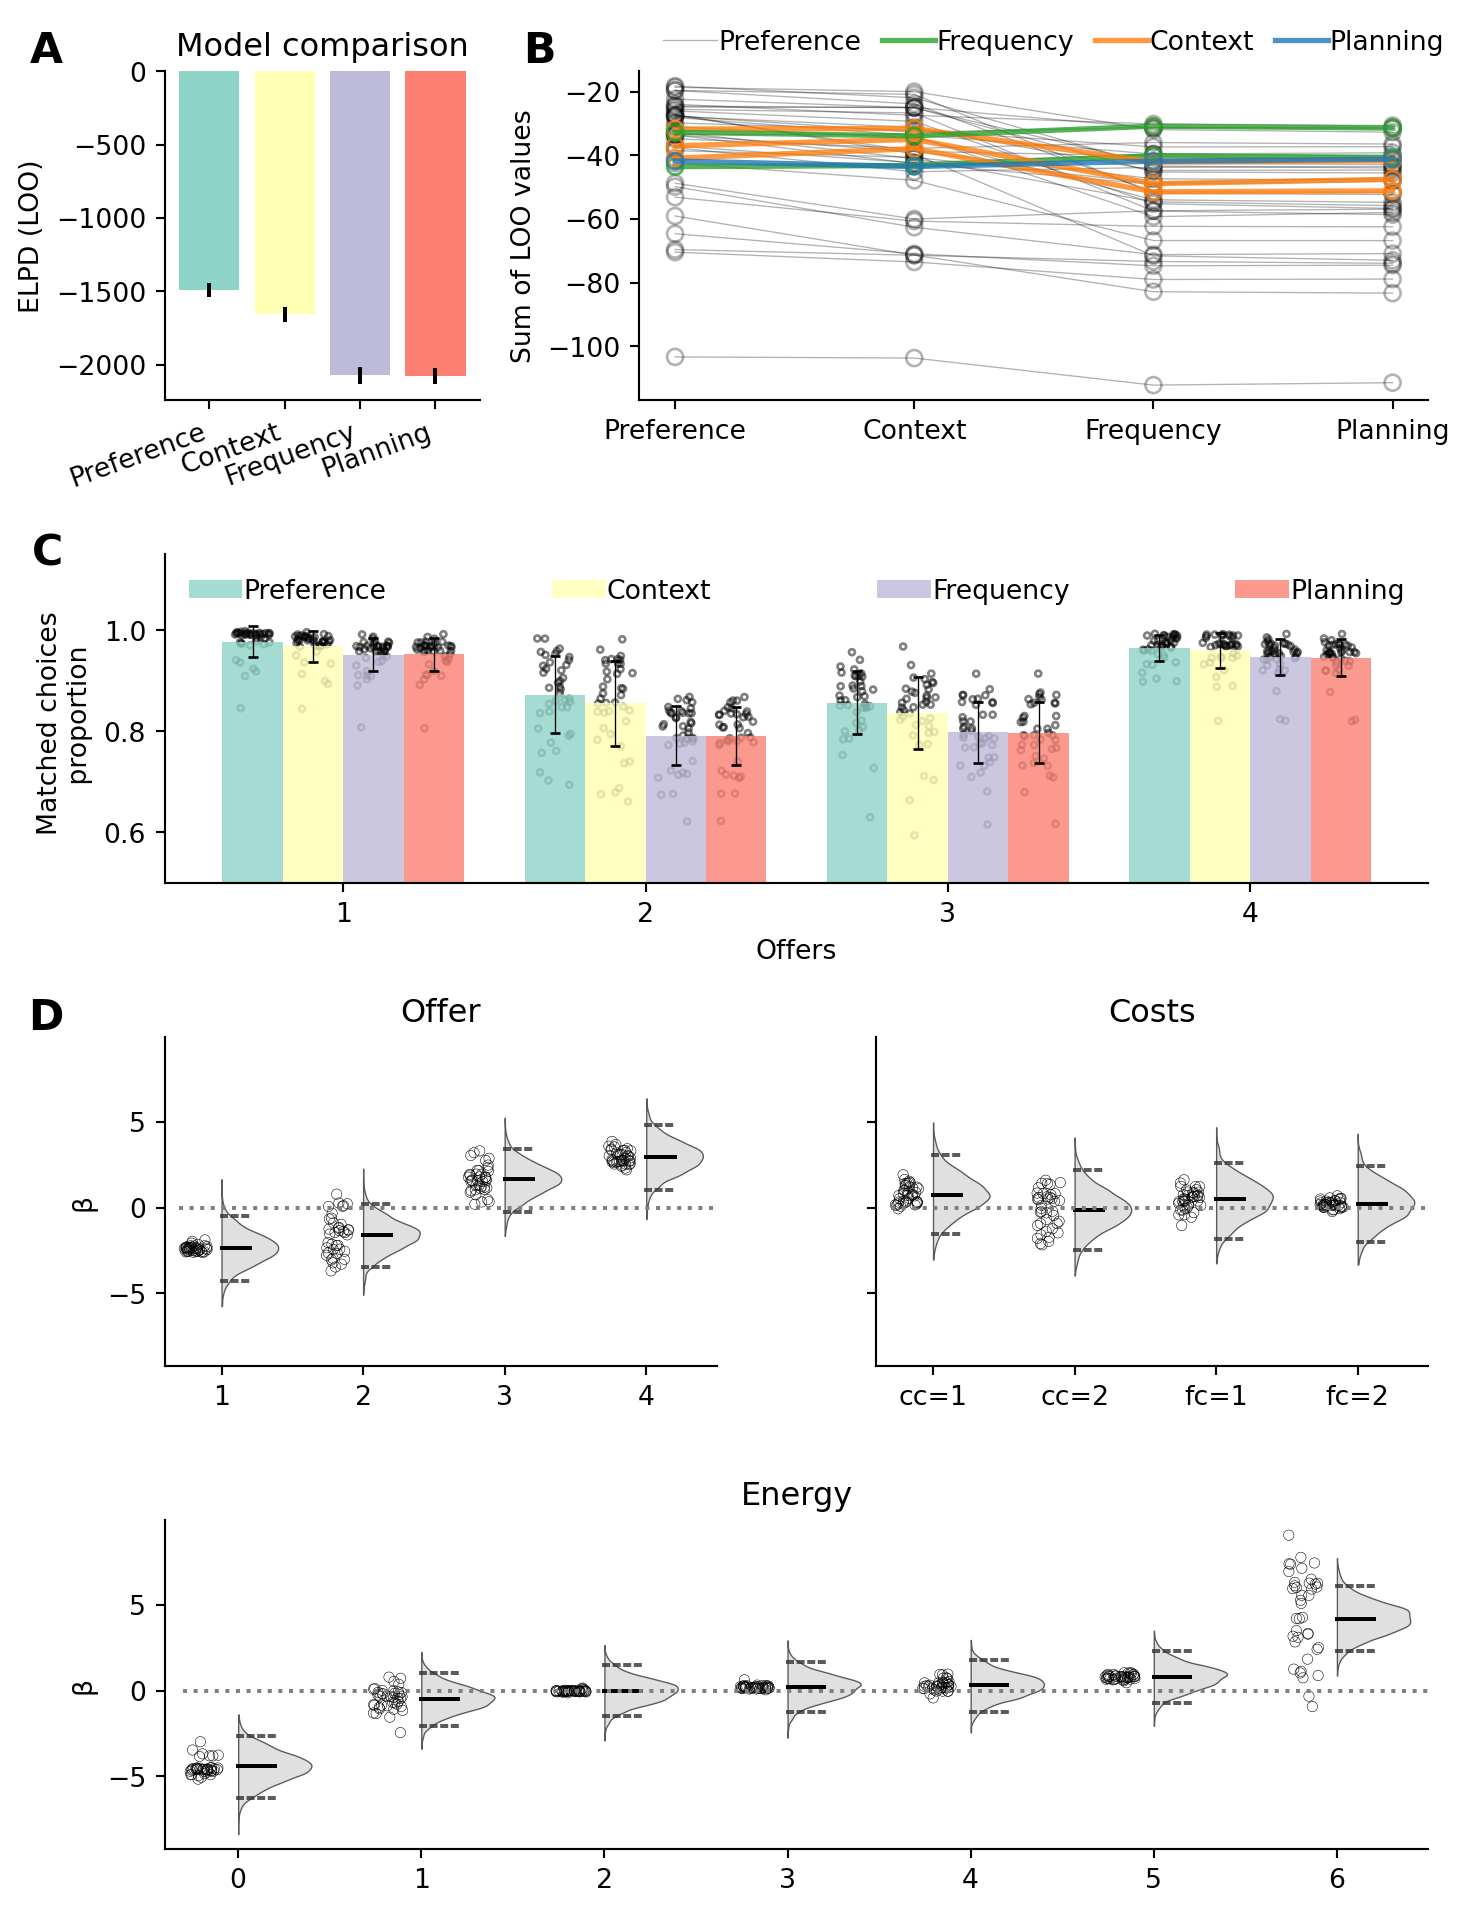

In [13]:
#| label: fig-choicemdl
#| fig-cap: 'Results of participants choice behaviour models. 
#| (A) Result of the model comparison, displaying the expected log pointwise predictive density (ELPD) associated with each model 
#| (closer to 0 indicate better fit, see @supptbl-model_comparison for model comparison results).
#| (B) Model fit for each participant, color coded per model of best fit. 
#| (C) Observed and fitted probability of accepting the offer separately for each offer by each of the models.
#| The single dots represent the average acceptance probability for each subject.
#| (D) Fitted preference parameters of the preference model. Top left figure depicts the parameters associated with
#| offer parameters, top right associated with each cost, bottom with each energy level. The bar in the middle of each 
#| distribution is the median and the dotted lines represent the 2.5 and 97.5% quantiles. The dots represent the mean of the 
#| parameter estimated for each participant'
fig, ax = plt.subplot_mosaic("AABBBB;CCCCCC;DDDEEE;FFFFFF", figsize=[A4_inches[0], 0.9*A4_inches[1]])
cmap = matplotlib.colormaps.get_cmap('Set3')
# ================================================
# fig-2A: model comparison:
# elpd_loo bar plot with error bar
ax["A"].bar(    
    [s.split(' ')[0] for s in model_comparison.index],
    model_comparison["elpd_loo"],
    yerr=model_comparison["se"],
    color=cmap(range(len(model_comparison)))
)
# Decoration
ax["A"].set_ylabel("ELPD (LOO)")
ax["A"].set_title("Model comparison")
ax["A"].set_xticklabels(ax["A"].get_xticklabels(), 
                        rotation=20, ha='right')
ax["A"].spines[['right', 'top']].set_visible(False)

# ================================================
# Single participant model fit:
ctr_mdl = {mdl: 0 for mdl in loo_results.keys()}
cmap = ["k", "tab:orange", "tab:green", "tab:blue"]
for sub in loos_sub['vpn']:
    # Extract the data from this participant:
    sub_loo = loos_sub[loos_sub["vpn"] == sub][loo_results.keys()]
    # Extract the winning model:
    winning = sub_loo.idxmax(axis=1).values[0]
    if ctr_mdl[winning] == 0:
        lbl = winning.split(' ')[0]
    else:
        lbl = None
    # Determine the color accordingly:
    c = cmap[list(loo_results.keys()).index(winning)]
    if winning == "Preference":
        alpha = 0.3
        zorder = 0
        linewidth=0.5
    else:
        alpha = 0.8
        zorder = 1000
        linewidth = 2
    ax["B"].scatter(range(len(traces)), np.squeeze(sub_loo.to_numpy()), color=c, alpha=alpha, facecolors='none', zorder=zorder)
    ax["B"].plot(range(len(traces)), np.squeeze(sub_loo.to_numpy()), color=c, label=lbl, alpha=alpha, zorder=zorder, linewidth=linewidth)
    ctr_mdl[winning] += 1
ax["B"].set_xticks(range(len(traces)))
ax["B"].set_xticklabels([s.split(' ')[0] for s in traces.keys()]) # , ha='right')
ax["B"].set_ylabel("Sum of LOO values")
ax["B"].spines[['right', 'top']].set_visible(False)
ax["B"].legend(frameon=False, mode="expand", loc="upper left", ncol=4, handletextpad=0.05, bbox_to_anchor=(0., 0.7, 1.05, 0.5)) 
# ax["B"].legend(frameon=False)

# ================================================
# fig-2C: Observed vs. fitted data of each model:
# Plot the true data against predicted values from each model:
pos = [1, 2, 3, 4, 6, 7, 8, 9, 11, 12, 13, 14, 16, 17, 18, 19]
cmap = matplotlib.colormaps.get_cmap('Set3')
ctr = 0
cols = [f"Match_{model_name.lower()}" for model_name in traces.keys()]
lbls = [s.split(' ')[0] for s in traces.keys()]
for o in [1, 2, 3, 4]:
    for col_i, col in enumerate(cols):
        # Group the data per participants:
        val = beh_data[beh_data['reward'] == o].groupby(['vpn'])[col].mean().reset_index()[col].to_numpy() 
        # Plot average across participants
        if o == 1:
            label = lbls[col_i]
        else:
            label = None

        # Plot single participants values:
        ax["C"].scatter(np.random.uniform(0.2, 0.8, len(val)) + pos[ctr]-1/2, val, s=5, marker="o", color='k', facecolors='none', alpha=0.5)
        ax["C"].bar(pos[ctr], np.mean(val), 
                    width=1, 
                    color=cmap(col_i), 
                    label=label,
                    alpha=0.8)
        # Add error bars:
        ax["C"].errorbar(pos[ctr], np.mean(val), yerr=np.std(val), color='k', capsize=2, linewidth=0.5)
        
        ctr += 1
ax["C"].set_xticks([2.5, 7.5, 12.5, 17.5])
ax["C"].set_xticklabels([1, 2, 3, 4])
ax["C"].set_ylim([0.5, 1.15])
ax["C"].set_xlabel("Offers")
ax["C"].set_ylabel("Matched choices \n proportion")
ax["C"].spines[['right', 'top']].set_visible(False)
ax["C"].legend(frameon=False, mode="expand", loc="upper left", ncol=4, handletextpad=0.05) # , bbox_to_anchor=(0., 0.9));

# ================================================
# fig-2D: Plot the preferences parameters of the preference model:
ylim = []
violinparts = []
width = 0.8

# ===========================
# Plot offer parameters:
data = []
for var in ["B_is_1", "B_is_2", "B_is_3", "B_is_4"]:
    vals = traces['Preference'].posterior["beta_pref"].sel(coef_pref=var).values.flatten()
    data.append(vals)
prts = ax["D"].violinplot(data, positions=range(len(data)), widths=width,
                    showmeans=False, showmedians=True,
                    showextrema=False, side="high", 
                    quantiles=[[0.025, 0.975]]*len(data));
violinparts.append(prts)
ax["D"].set_xticks(range(len(data)))
ax["D"].set_xticklabels([1, 2, 3, 4])
ax["D"].set_ylabel("β")
ax["D"].hlines(0, -0.3, 3.5, color='gray', linestyles=':')
ax["D"].set_xlim([-0.4, 3.5])
ax["D"].spines[['right', 'top']].set_visible(False)
ax["D"].set_title("Offer")

# Plot the single participants fit:
data = []
positions = []
for i, var in enumerate(["B_is_1", "B_is_2", "B_is_3", "B_is_4"]):
    vals = traces['Preference'].posterior["beta_pref_sub"].sel(coef_pref=var).mean(dim=["chain", "draw"]).values
    data.append(vals)
    positions.append(np.random.uniform(low=i - (width*1/3), high=i-width*1/8, size=len(vals)))
ax["D"].scatter(positions, data, s=15, c='None', edgecolors="k", linewidth=0.2)
ylim.append(ax["D"].get_ylim())

# ===========================
# Plot Costs parameters:
data = []
for var in ["B_is_lc", "B_is_hc", "B_is_lfc", "B_is_hfc"]:
    vals = traces['Preference'].posterior["beta_pref"].sel(coef_pref=var).values.flatten()
    data.append(vals)
prts = ax["E"].violinplot(data, positions=range(len(data)), widths=width,
                    showmeans=False, showmedians=True,
                    showextrema=False, side="high",
                    quantiles=[[0.025, 0.975]]*len(data));
violinparts.append(prts)
ax["E"].set_xticks(range(len(data)))
ax["E"].set_xticklabels(['cc=1', 'cc=2', 'fc=1', 'fc=2'])
ax["E"].set_yticklabels([])
ax["E"].hlines(0, -0.3, 3.5, color='gray', linestyles=':')
ax["E"].set_xlim([-0.4, 3.5])
ax["E"].spines[['right', 'top']].set_visible(False)
ax["E"].set_title("Costs")

# Plot the single participants fit:
data = []
positions = []
for i, var in enumerate(["B_is_lc", "B_is_hc", "B_is_lfc", "B_is_hfc"]):
    vals = traces['Preference'].posterior["beta_pref_sub"].sel(coef_pref=var).mean(dim=["chain", "draw"]).values
    data.append(vals)
    positions.append(np.random.uniform(low=i - (width*1/3), high=i-width*1/8, size=len(vals)))
ax["E"].scatter(positions, data, s=15, c='None', edgecolors="k", linewidth=0.2)
ylim.append(ax["D"].get_ylim())

# ===========================
# Plot energy parameters:
data = []
for var in ["B_e_is_0", "B_e_is_1", "B_e_is_2", "B_e_is_3", 
            "B_e_is_4", "B_e_is_5", "B_e_is_6"]:
    vals = traces['Preference'].posterior["beta_pref"].sel(coef_pref=var).values.flatten()
    data.append(vals)
prts = ax["F"].violinplot(data, positions=range(len(data)), widths=width, 
                     showmeans=False, showmedians=True,
                     showextrema=False, side="high",
                     quantiles=[[0.025, 0.975]]*len(data));
violinparts.append(prts)
ax["F"].set_xticks(range(len(data)))
ax["F"].set_xticklabels([0, 1, 2, 3, 4, 5, 6])
ax["F"].hlines(0, -0.3, 6.5, color='gray', linestyles=':')
ax["F"].set_xlim([-0.4, 6.5])
ax["F"].set_title('Energy')
ax["F"].spines[['right', 'top']].set_visible(False)
ax["F"].set_ylabel("β")

# Plot the single participants fit:
data = []
positions = []
for i, var in enumerate(["B_e_is_0", "B_e_is_1", "B_e_is_2", "B_e_is_3", 
                         "B_e_is_4", "B_e_is_5", "B_e_is_6"]):
    vals = traces['Preference'].posterior["beta_pref_sub"].sel(coef_pref=var).mean(dim=["chain", "draw"]).values
    data.append(vals)
    positions.append(np.random.uniform(low=i - (width*1/3), high=i-width*1/8, size=len(vals)))
ax["F"].scatter(positions, data, s=15, c='None', edgecolors="k", linewidth=0.2)

# ax_energy.set_title("Energy parameters")
ylim.append(ax["F"].get_ylim())

ax["D"].set_ylim([np.min(ylim), np.max(ylim)])
ax["E"].set_ylim([np.min(ylim), np.max(ylim)])
ax["F"].set_ylim([np.min(ylim), np.max(ylim)])

# Adjust the aspect of the violins
for prts in violinparts:
    for pc in prts['bodies']:
        pc.set_facecolor(cmap(8))
        pc.set_edgecolor([0.2, 0.2, 0.2, 0.8])
        pc.set_linewidth(0.5)
        pc.set_alpha(0.8)
    prts['cquantiles'].set_color([0.2, 0.2, 0.2])
    prts['cquantiles'].set_linestyle(":")
    prts['cquantiles'].set_alpha(0.8)
    prts['cmedians'].set_color("k")
plt.tight_layout()
ax["A"].text(0.05, 0.98, "A", transform=fig.transFigure, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
ax["B"].text(0.38, 0.98, "B", transform=fig.transFigure, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
ax["C"].text(0.05, 0.72, "C", transform=fig.transFigure, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
# Add ax label:
ax["D"].text(0.05, 0.48, "D", transform=fig.transFigure, 
                fontsize=16, fontweight='bold', va='top', ha='right'
                );


In [14]:
# Calculate the interaction confidence intervals:
mu_interaction = traces['Preference'].posterior["beta_interaction"].values.flatten().mean()
ci_interaction = az.hdi(traces['Preference'].posterior["beta_interaction"].values)[0]

We next tested the central prediction that the influence of planning should depend on the certainty of the preference signal. The preference model revealed a positive modulation of planning by preference entropy ($\beta_{modulation}$=`{python} f"{mu_interaction:.2f}"`, CI=[`{python} f"{ci_interaction[0]:.2f}, {ci_interaction[1]:.2f}"`]), indicating that planning-derived DV had a stronger influence on choices when preferences were more uncertain. Conversely, when preferences were strong, choices were less sensitive to planning-derived decision values and were more strongly guided by the preference component.

To visualize this effect, we plotted the fitted probability of accepting as a function of planning-derived DV for different preferences values (see @fig-pref-planning-interaction A). This visualization shows the model-implied effect directly: the choice curve is steeper when preferences entropy is high (preference scores close to 0), indicating stronger reliance on planning, and flatter are preferences entropy increases (preference scores away from 0, deep blue and deep red lines in @fig-pref-planning-interaction A), indicating that choices are already largely determined by the preference signal. @fig-pref-planning-interaction B shows the observed probability of accepting the offer as a function of DV, separately when preferences were positive (upper panel) and negative (lower panel), further showing the effect of preferences on participants response choice: participants accept offer at lower DV when preference scores are positive compared to when preference scores are negative (@suppfig-pref-planning-interaction shows participants responses and fitted values as a function of DV and preferences without binning). 

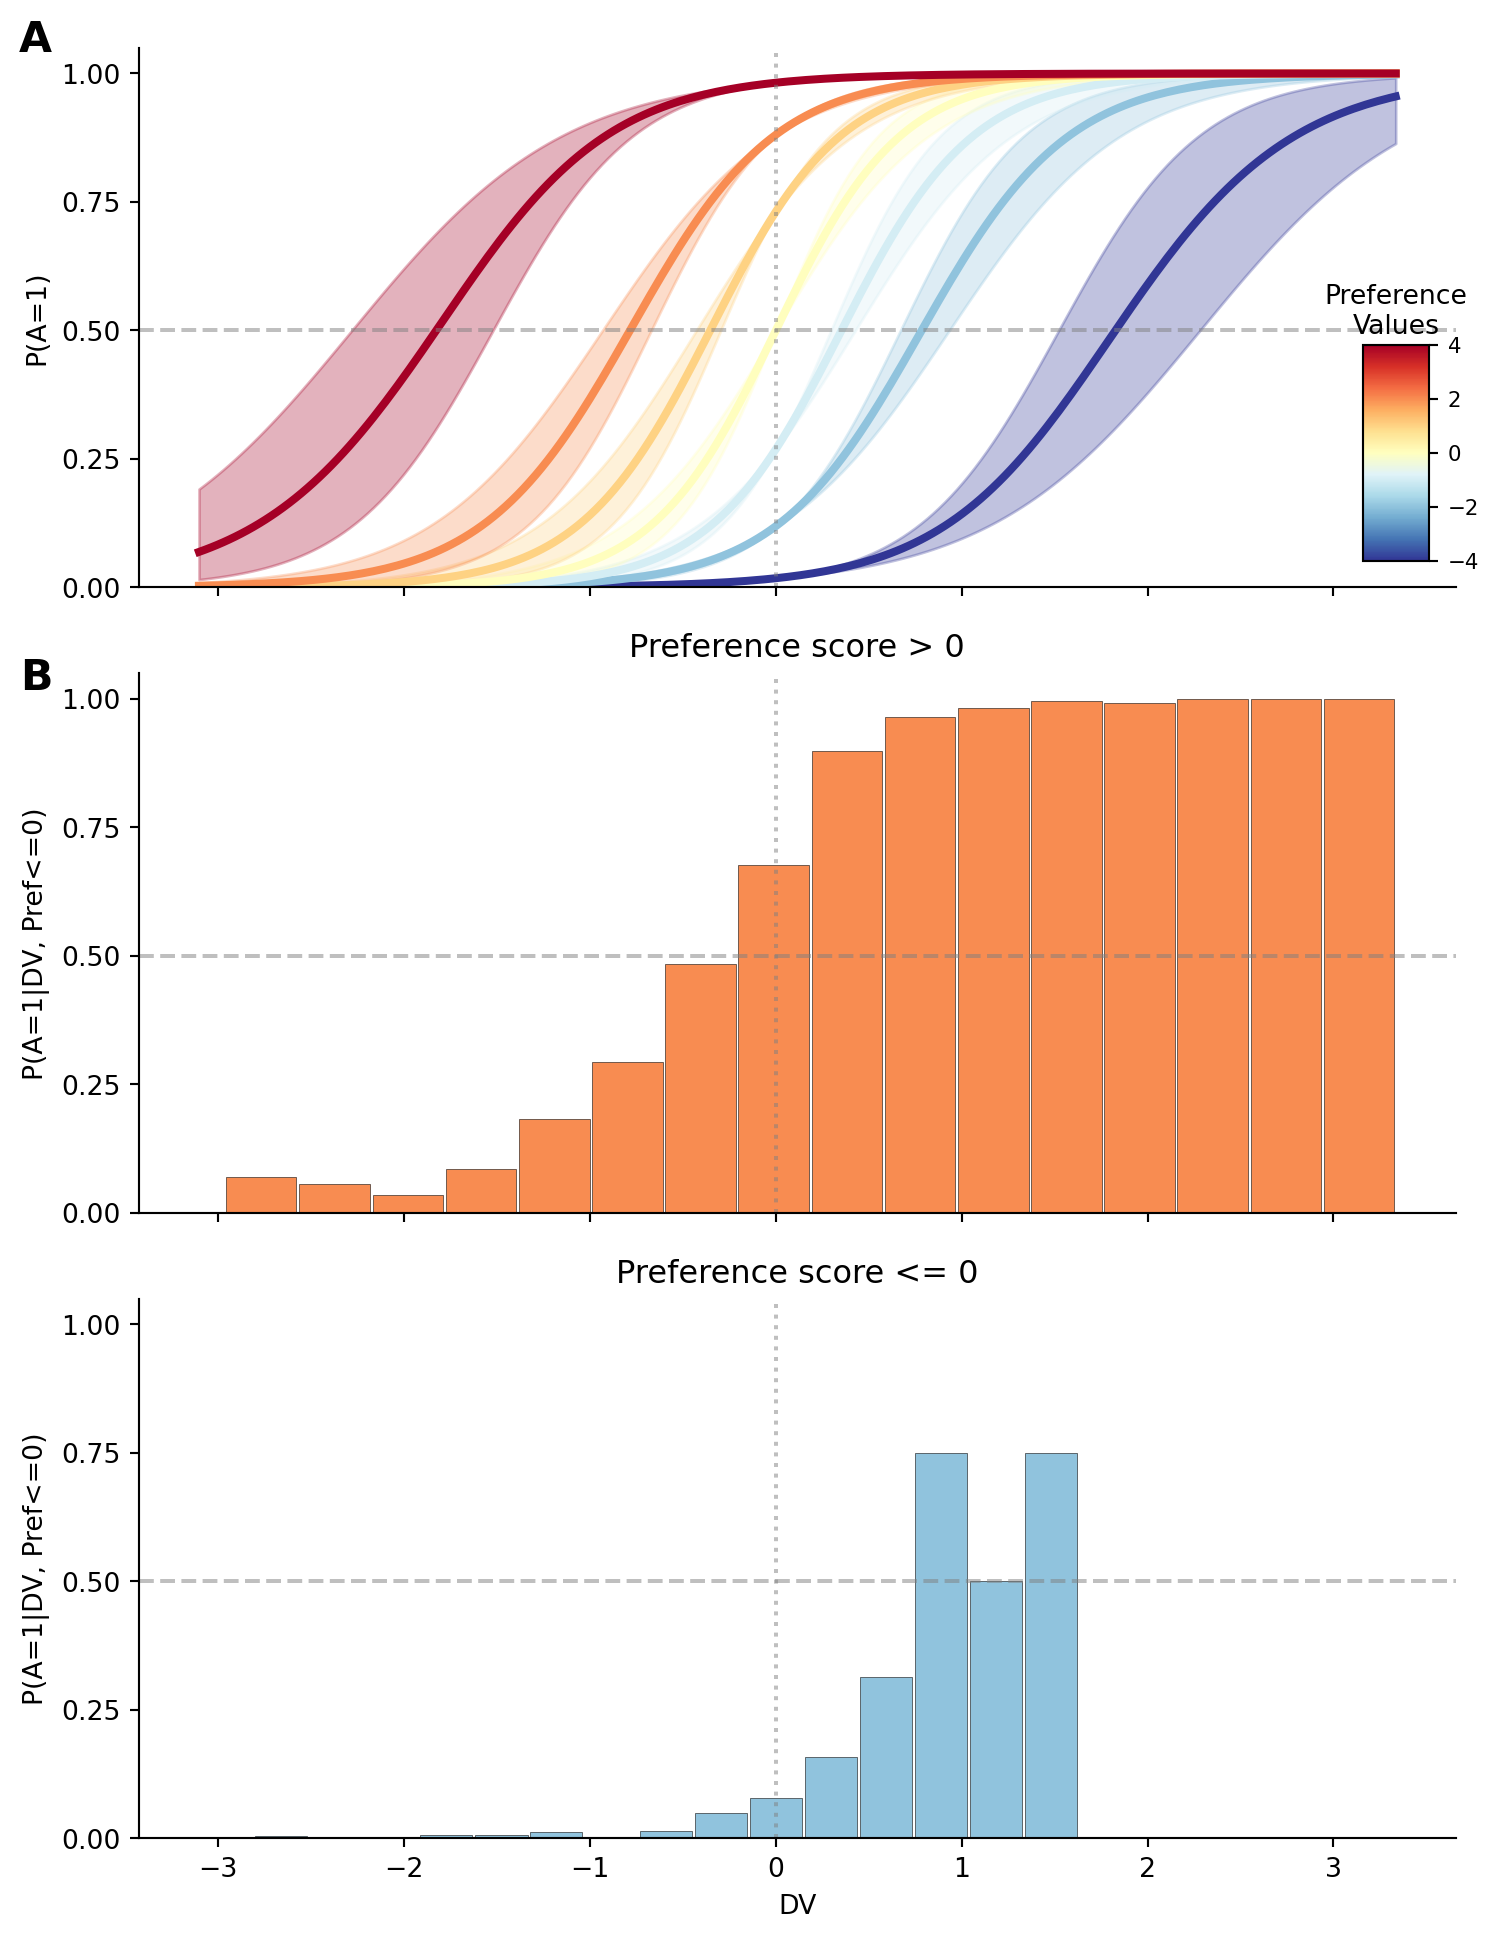

In [15]:
#| label: fig-pref-planning-interaction
#| fig-cap: "Relationship between preferences and DV. (A) Fitted probability of accepting an offer as a function of planning DV, separately for preference score of 
#| [-4, -2, -1, 0, 1, 2, 4], to highlight the interaction between preferences scores and DV. Line represents mean of posterior distribution, shaded area is 95% C.I. 
#| (B) Offer acceptance probability (y-axis) binned per decision values (x-axis), separately for trials in which preference score is positive (top row, red bars) 
#| (bottom row, blue bars)."
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplot_mosaic("A;B;C", figsize=[A4_inches[0], 0.9*A4_inches[1]], sharex=True, sharey=True)
cmap = matplotlib.colormaps.get_cmap('RdYlBu_r')
# Create DV:
x_dv = np.linspace(beh_data['dv'].min(), beh_data['dv'].max(), 200)
pref_scores = [-4, -2, -1, 0, 1, 2, 4]
# Create a colormap and normalization for the colorbar
cmap = plt.cm.RdYlBu_r  # Choose a colormap
norm = Normalize(vmin=min(pref_scores), vmax=max(pref_scores))  # Normalize preference values

for i, pref in enumerate(pref_scores):
    p_a, lower_95, upper_95 = predict_responses(x_dv, pref, traces["Preference"])
    ax["A"].plot(x_dv, p_a, c=cmap(norm(pref)), linewidth=3)
    ax["A"].fill_between(x_dv, lower_95, upper_95, color=cmap(norm(pref)), alpha=0.3)
ax["A"].set_ylabel("P(A=1)")
ax["A"].axvline(0, linestyle=":", color="grey", alpha=0.5)
ax["A"].axhline(0.5, linestyle="--", color="grey", alpha=0.5)
ax["A"].spines[['top', 'right']].set_visible(False)
# Add an inset colorbar
cax = inset_axes(ax["A"], width="5%", height="40%", loc="lower right", borderpad=1)  # Adjust size and position
sm = ScalarMappable(cmap=cmap, norm=norm)  # Create a ScalarMappable for the colorbar
sm.set_array([])  # Dummy array for ScalarMappable
cbar = fig.colorbar(sm, cax=cax, orientation='vertical')  # Add horizontal colorbar
cbar.ax.set_title("Preference\nValues", fontsize=10, pad=4)  # Label above the 
cbar.ax.tick_params(labelsize=8)  # Adjust tick size

# ================================================================
# fig-3C: Response probability binned per decision value for negative preferences
pref_positive = beh_data[beh_data['preference_score'] > 0]
# Bin the data:
bins = pd.cut(pref_positive['dv'], bins=16)
pa_pref_positive = pref_positive.groupby(bins)['response'].mean()
position = pd.IntervalIndex(pa_pref_positive.index).mid
ax["B"].bar(   
    position.to_numpy(), 
    pa_pref_positive.to_numpy(),
    facecolor=cmap(0.75),
    width=pd.IntervalIndex(pa_pref_positive.index).length[0]-0.02,
    edgecolor='k',
    linewidth=0.2
)
ax["B"].set_yticks([0, 0.25, 0.5, 0.75, 1])
ax["B"].axvline(0, linestyle=":", color="grey", alpha=0.5)
ax["B"].axhline(0.5, linestyle="--", color="grey", alpha=0.5)
ax["B"].set_ylabel("P(A=1|DV, Pref<=0)")
ax["B"].set_title('Preference score > 0')
ax["B"].spines[['top', 'right']].set_visible(False)

# ================================================================
# fig-3C: Response probability binned per decision value for negative preferences
pref_negative = beh_data[beh_data['preference_score'] <= 0]
# Bin the data:
bins = pd.cut(pref_negative['dv'], bins=16)
pa_pref_negative = pref_negative.groupby(bins)['response'].mean()
position = pd.IntervalIndex(pa_pref_negative.index).mid
ax["C"].bar(   
    position.to_numpy(), 
    pa_pref_negative.to_numpy(),
    facecolor=cmap(0.25),
    width=pd.IntervalIndex(pa_pref_negative.index).length[0]-0.02,
    edgecolor='k',
    linewidth=0.2
)
ax["C"].set_yticks([0, 0.25, 0.5, 0.75, 1])
ax["C"].set_xlabel("DV")
ax["C"].set_title('Preference score <= 0')
ax["C"].axvline(0, linestyle=":", color="grey", alpha=0.5)
ax["C"].axhline(0.5, linestyle="--", color="grey", alpha=0.5)
ax["C"].set_ylabel("P(A=1|DV, Pref<=0)")
ax["C"].spines[['top', 'right']].set_visible(False)
plt.tight_layout()
ax["A"].text(0.04, 1, "A", transform=fig.transFigure, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
ax["B"].text(0.04, 0.67, "B", transform=fig.transFigure, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              );

In [16]:
from scipy.stats import zscore
# Compute correlation between models parameters and return:
# Get the return from each subject:
subjects_returns = []
for sub in beh_data['vpn'].unique():
    subjects_returns.append(beh_data[beh_data['vpn'] == sub]["points"].to_numpy()[-1])
subjects_returns = np.array(subjects_returns)

# Z score participants returns to identify outliers:
zscore_return = zscore(subjects_returns)
min_return_sd = np.abs(min(zscore_return))
outlier_mask = [i for i, _ in enumerate(subjects_returns) if subjects_returns[i] != min(subjects_returns)]

# ==========================================================
# Planning and return:
# Get the corresponding planning beta from the preference model:
planning_betas = np.squeeze(np.mean(traces['Preference'].posterior["beta_planning_sub"], axis=(0, 1)).to_numpy())
# Compute correlation coefficient:
r = pearsonr(planning_betas, subjects_returns)
r_planning, pval_planning = r.statistic, r.pvalue

# Removing the outlier:
r = pearsonr(planning_betas[outlier_mask], subjects_returns[outlier_mask])
r_planning_no_outlier, pval_planning_no_outlier = r.statistic, r.pvalue

# ==========================================================
# Pref entropy & return
# Get the entropy:
beh_data['entropy'] = np.mean(traces['Preference'].posterior["entropy"], axis=(0, 1))
pref_entropy = beh_data.groupby('vpn')['entropy'].mean().reset_index()['entropy'].to_numpy()
# Compute correlation coefficient:
r = pearsonr(pref_entropy, subjects_returns)
r_pref, pval_pref = r.statistic, r.pvalue

# Removing the outlier:
r = pearsonr(pref_entropy[outlier_mask], subjects_returns[outlier_mask])
r_pref_no_outlier, pval_pref_no_outlier = r.statistic, r.pvalue

# ==========================================================
# Interaction & return
# Get the entropy:
interaction_beta = np.squeeze(np.mean(traces['Preference'].posterior["beta_interaction_sub"], axis=(0, 1)).to_numpy())
# Compute correlation coefficient:
r = pearsonr(interaction_beta, subjects_returns)
r_interaction, pval_interaction = r.statistic, r.pvalue

# Removing the outlier:
r = pearsonr(interaction_beta[outlier_mask], subjects_returns[outlier_mask])
r_interaction_no_outlier, pval_interaction_no_outlier = r.statistic, r.pvalue

We next asked whether these model components were behaviourally meaningful beyond predicting individual choices. Specifically, we tested whether overall task performance was related to participants’ reliance on planning, the strength of their task-structured preferences, and the extent to which preference uncertainty modulated planning. As larger $\beta_{planning}$ values indicate stronger reliance on planning, we expected participants with larger $\beta_{planning}$ to obtain higher returns. In contrast to planning, preferences might not necessarily maximize reward, so participants with strong preferences (i.e. low preference entropy) should obtain lower return on average. Finally, larger $\beta_{modulation}$ indicate that participants plan more when their preferences are weak (i.e. preferences entropy is larger), and should accordingly obtain larger returns compared to participants’ who do not engage more strongly in planning when their preferences are weak. Accordingly, we predicted that $\beta_{planning}$, preferences entropy and $\beta_{modulation}$ should be positively correlated with return. 

In line with our prediction, we observed a positive correlation between $\beta_{planning}$ and return (r=`{python} f"{r_planning:.2f}"`, p=`{python} f"{pval_planning:.3f}"`, @fig-returns A), showing that participants who rely more on planning get larger return. Furthermore, $\beta_{modulation}$ is strongly and positively correlated with return (r=`{python} f"{r_interaction:.2f}"`, p=`{python} f"{pval_interaction:.3f}"`, @fig-returns B). However, contrary to our prediction, we observed a negative correlation though only marginally significant correlation between preferences entropy and return (r=`{python} f"{r_pref:.2f}"`, p=`{python} f"{pval_pref:.3f}"`, @fig-returns C). Visual inspection of @fig-returns D revealed that the correlation appears to be driven from the subject with very low return (`{python} f"{min_return_sd:.2f}"` standard deviations from population mean). When removing this subject, the correlation between preferences entropy and return is not marginally significant (r=`{python} f"{r_pref_no_outlier:.2f}"`, p=`{python} f"{pval_pref_no_outlier:.3f}"`), while it remains strongly significant for planning (r=`{python} f"{r_planning_no_outlier:.2f}"`, p=`{python} f"{pval_planning_no_outlier:.3f}"`) and modulation (r=`{python} f"{r_interaction_no_outlier:.2f}"`, p=`{python} f"{pval_interaction_no_outlier:.3f}"`) when the same subject is removed. 

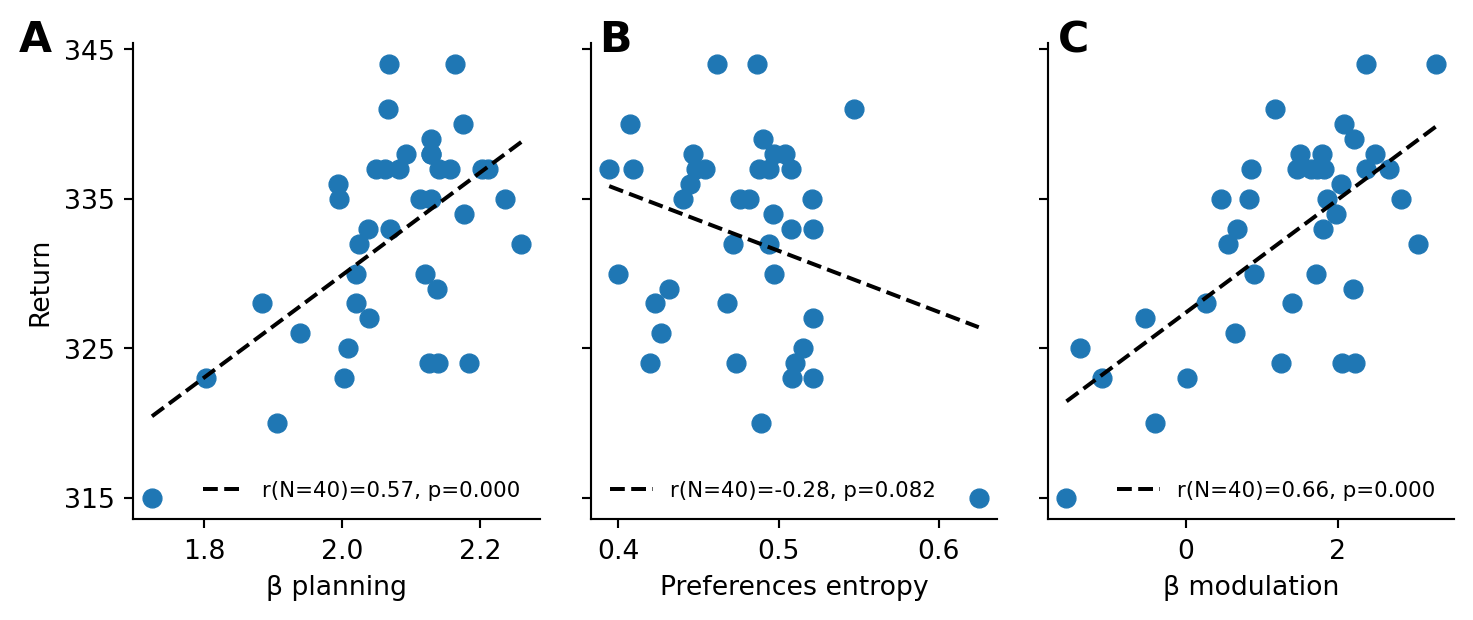

In [17]:
#| label: fig-returns
#| fig-cap: "Single participants fit and performances (A) Model fit for each participant, color coded per model of best fit. (B) Correlation between participants return and the fitted 
#| $\\beta_{planning}$ parameter. Each dot represent a single participant, the line is a correlation fitted using optimal least square, legend indicates pearson
#| correlation alongside p value. (C) Correlation between participants performances and the average preference entropy. Same convention as (B). (C) Correlation 
#| between participants performances and $\\beta_{modulation}$. Same convention as (B)"
fig, ax = plt.subplot_mosaic("ABC", figsize=[A4_inches[0], 0.3*A4_inches[1]], sharey=True)

# ================================================================
# fig-3B: Plot the correlation between total return and the planning weight:
# Sort according to beta strength:
order = np.argsort(planning_betas)
# Plot correlation between the two:
coef = np.polyfit(np.squeeze(planning_betas[order]), subjects_returns[order], 1)
poly1d_fn = np.poly1d(coef)
ax["A"].scatter(np.squeeze(planning_betas[order]), subjects_returns[order],linewidths=0.5, s=50)
ax["A"].plot(np.squeeze(planning_betas[order]), poly1d_fn(np.squeeze(planning_betas[order])), 
             color='k', linestyle='--', label=f'r(N={len(subjects_returns)})={r_planning:.2f}, p={pval_planning:.3f}')
ax["A"].set_xlabel("β planning")
ax["A"].set_ylabel("Return")
ax["A"].set_yticks([315, 325, 335, 345])
ax["A"].set_yticklabels([315, 325, 335, 345])
ax["A"].text(-0.2, 1.05, "A", transform=ax["A"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
ax["A"].spines[['right', 'top']].set_visible(False)
ax["A"].legend(frameon=False, prop={'size': 8})

# ================================================================
# fig-3C: Plot the correlation between total return and the preferences entropy:
order = np.argsort(pref_entropy)
# Plot correlation between the two:
coef = np.polyfit(np.squeeze(pref_entropy[order]), subjects_returns[order], 1)
poly1d_fn = np.poly1d(coef)
ax["B"].scatter(pref_entropy[order], subjects_returns[order], linewidths=0.5, s=50)
ax["B"].plot(pref_entropy[order], poly1d_fn(pref_entropy[order]), color='k', linestyle='--', 
             label=f'r(N={len(subjects_returns)})={r_pref:.2f}, p={pval_pref:.3f}')
ax["B"].set_xlabel("Preferences entropy")
# ax["B"].set_ylabel("Return")
ax["B"].set_yticks([315, 325, 335, 345])
ax["B"].set_yticklabels([315, 325, 335, 345])
ax["B"].text(0.1, 1.05, "B", transform=ax["B"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
ax["B"].spines[['right', 'top']].set_visible(False)
ax["B"].legend(frameon=False, prop={'size': 8})

# ================================================================
# fig-3D: Plot the correlation between total return and the preferences entropy:
order = np.argsort(interaction_beta)
# Plot correlation between the two:
coef = np.polyfit(np.squeeze(interaction_beta[order]), subjects_returns[order], 1)
poly1d_fn = np.poly1d(coef)
ax["C"].scatter(interaction_beta[order], subjects_returns[order], linewidths=0.5, s=50)
ax["C"].plot(interaction_beta[order], poly1d_fn(interaction_beta[order]), color='k', linestyle='--', 
             label=f'r(N={len(subjects_returns)})={r_interaction:.2f}, p={pval_interaction:.3f}')
ax["C"].set_xlabel("β modulation")
ax["C"].set_yticks([315, 325, 335, 345])
ax["C"].set_yticklabels([315, 325, 335, 345])
ax["C"].text(0.1, 1.05, "C", transform=ax["C"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
ax["C"].spines[['right', 'top']].set_visible(False)
ax["C"].legend(frameon=False, prop={'size': 8})
plt.tight_layout();

### Experimental factors relevance

Our results indicate that participants' choices are shaped by two sources of information: planning-derived values and task-structured preferences. These preferences are not a single global bias. Instead, participants appear to assign preferences to different features of the task, such as the offer, the current cost context, and upcoming transitions, and combine these feature-specific preferences into an overall preference for each action in a given state. Importantly, not all features of the task are weighted equally. @fig-choicemdl C shows that the parameters associated with offers and energy weigh strongly in participants’ preferences compared to costs (both current and future). The fitted preference weights already suggested that participants’ preferences were structured primarily by offer value and energy. We next asked whether the same pattern was evident from a complementary model-comparison perspective. To do so, we compared the full preference model with reduced models in which the preference terms for one task factor were removed at a time. This effectively tests how decision making changes when participants are assumed to ignore one specific sources of task information, such as offer value, action costs, or future transitions. 

In [18]:
# Full model:
traces_reduced = {"Preference": traces["Preference"]}

if os.path.exists("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_offer_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_offer_trace.nc")
    traces_reduced['Offer'] = idata
else:
    preference_columns = [
        'is_lc', 'is_hc', 
        'is_lfc', 'is_hfc',
        'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6'
    ]
    idata = preference_model(beh_data['response'],  # Subjects responses
                                np.squeeze(beh_data[['dv']].to_numpy()),  # Optimal decision values
                                beh_data[preference_columns],  # Preferences regressors
                                subj_idx_raw, subj_labels)
    # Add the idata to the rest:
    traces_reduced['Offer'] = idata
    # Save the trace to file:
    az.to_netcdf(traces_reduced['Offer'], "./data/bids/limited_energy/derivatives/control_models/preferences_model_no_offer_trace.nc")

# Fit the model without the offer related preferences:
if os.path.exists("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_costs_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_costs_trace.nc")
    traces_reduced['CC'] = idata
else:
    # Fit the model without the costs related preferences:
    preference_columns = [
        'is_1', 'is_2', 'is_3', 'is_4', 
        'is_lfc', 'is_hfc',
        'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6'
    ]
    idata = preference_model(beh_data['response'],  # Subjects responses
                                np.squeeze(beh_data[['dv']].to_numpy()),  # Optimal decision values
                                beh_data[preference_columns],  # Preferences regressors
                                subj_idx_raw, subj_labels)
    # Add the idata to the rest:
    traces_reduced['CC'] = idata
    # Save the trace to file:
    az.to_netcdf(traces_reduced['CC'], "./data/bids/limited_energy/derivatives/control_models/preferences_model_no_costs_trace.nc")

# Fit the model without the offer related preferences:
if os.path.exists("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_fc_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_fc_trace.nc")
    traces_reduced['FC'] = idata
else:
    # Fit the model without the transitions related preferences:
    preference_columns = [
        'is_1', 'is_2', 'is_3', 'is_4', 
        'is_lc', 'is_hc', 
        'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6'
    ]
    idata = preference_model(beh_data['response'],  # Subjects responses
                                np.squeeze(beh_data[['dv']].to_numpy()),  # Optimal decision values
                                beh_data[preference_columns],  # Preferences regressors
                                subj_idx_raw, subj_labels)
    # Add the idata to the rest:
    traces_reduced['FC'] = idata
    # Save the trace to file:
    az.to_netcdf(traces_reduced['FC'], "./data/bids/limited_energy/derivatives/control_models/preferences_model_no_fc_trace.nc")

# Fit the model without the offer related preferences:
if os.path.exists("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_energy_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_energy_trace.nc")
    traces_reduced['Energy'] = idata
else:
    # Fit the model without the energy related preferences:
    preference_columns = [
        'is_1', 'is_2', 'is_3', 'is_4', 
        'is_lc', 'is_hc', 
        'is_lfc', 'is_hfc',
    ]
    idata = preference_model(beh_data['response'],  # Subjects responses
                                np.squeeze(beh_data[['dv']].to_numpy()),  # Optimal decision values
                                beh_data[preference_columns],  # Preferences regressors
                                subj_idx_raw, subj_labels)
    # Add the idata to the rest:
    traces_reduced['Energy'] = idata
    # Save the trace to file:
    az.to_netcdf(traces_reduced['Energy'], "./data/bids/limited_energy/derivatives/control_models/preferences_model_no_energy_trace.nc")

# Compare against the full model:
model_comparison = az.compare(traces_reduced)

@fig-task-features A displays the difference in fit between the full preference model against models in which the preferences related to each experimental factor were removed one by one. Larger values indicate that the specific factor is more relevant for the full model’s fit. These results indicate that offer ($\Delta ELPD_{full - offer}$=`{python} f"{model_comparison.loc["Offer", "elpd_diff"]:.2f}"` $\pm$ `{python} f"{model_comparison.loc["Offer", "se"]:.2f}"` s.e.), followed by energy ($\Delta ELPD_{full - energy}$=`{python} f"{model_comparison.loc["Energy", "elpd_diff"]:.2f}"` $\pm$ `{python} f"{model_comparison.loc["Energy", "se"]:.2f}"` s.e.), has a much larger impact on participants final responses, whereas costs-related preferences have a smaller impact on the overall fit ($\Delta ELPD_{full - CC}$=`{python} f"{model_comparison.loc["CC", "elpd_diff"]:.2f}"` $\pm$ `{python} f"{model_comparison.loc["CC", "se"]:.2f}"` s.e. and $\Delta ELPD_{full - FC}$=`{python} f"{model_comparison.loc["FC", "elpd_diff"]:.2f}"` $\pm$ `{python} f"{model_comparison.loc["FC", "se"]:.2f}"` s.e.).

In [19]:
# Compute the reduced MDPs:
return_reduced = {
    "Offer": None,
    "Energy": None,
    "CC": None,
    "FC": None,
}
max_return = task_mdp.expected_return(task_mdp.greedy_policy(Q_full), initial_energy=3)

# ==================================================================
# Offer reduced MDP:
# Get all single states without the offers:
inds = [0, 2, 3, 4]
states_no_offers = list(set(tuple([state[i] for i in inds]) for state in task_mdp.states))
# Create state classes, i.e. list of states groups that share everything but the offer:
states_classes = []
for state_r in states_no_offers:
    class_ = []
    for state in task_mdp.states:
        if tuple(state[i] for i in inds) == state_r:
            class_.append(state)
    states_classes.append(class_)
# Reduce the MDP accordingly:
statesR, tpR, rR, class_of_state = avg_reduce_mdp(states_classes, task_mdp.tp, task_mdp.r, task_mdp.s2i)
# Create abstract MDP:
V_R, Q_R = MDP(statesR, tpR, rR, gamma).backward_induction()
# Project back to ground space:
_, Q = abstract2ground_value(class_of_state, V_R, Q_R)
# Compute the expected return:
return_reduced["Offer"] = 1 - (task_mdp.expected_return(task_mdp.greedy_policy(Q), initial_energy=3) / max_return)

# ==================================================================
# Energy reduced MDP:
# Get all single states without the Energy:
inds = [1, 2, 3, 4]
states_no_energy =  list(set(tuple([state[i] for i in inds]) for state in task_mdp.states))
# Create state classes, i.e. list of states groups that share everything but the offer:
states_classes = []
for state_r in states_no_energy:
    class_ = []
    for state in task_mdp.states:
        if tuple(state[i] for i in inds) == state_r:
            class_.append(state)
    states_classes.append(class_)
# Reduce the MDP accordingly:
statesR, tpR, rR, class_of_state = avg_reduce_mdp(states_classes, task_mdp.tp, task_mdp.r, task_mdp.s2i)
# Create abstract MDP:
V_R, Q_R = MDP(statesR, tpR, rR, gamma).backward_induction()
# Project back to ground space:
_, Q = abstract2ground_value(class_of_state, V_R, Q_R)
# Compute the expected return:
return_reduced["Energy"] = 1 - (task_mdp.expected_return(task_mdp.greedy_policy(Q), initial_energy=3) / max_return)

# ==================================================================
# CC reduced MDP:
# Get all single states without the offers:
inds = [0, 1, 3, 4]
states_no_cc=  list(set(tuple([state[i] for i in inds]) for state in task_mdp.states))
# Create state classes, i.e. list of states groups that share everything but the offer:
states_classes = []
for state_r in states_no_cc:
    class_ = []
    for state in task_mdp.states:
        if tuple(state[i] for i in inds) == state_r:
            class_.append(state)
    states_classes.append(class_)
# Reduce the MDP accordingly:
statesR, tpR, rR, class_of_state = avg_reduce_mdp(states_classes, task_mdp.tp, task_mdp.r, task_mdp.s2i)
# Create abstract MDP:
V_R, Q_R = MDP(statesR, tpR, rR, gamma).backward_induction()
# Project back to ground space:
_, Q = abstract2ground_value(class_of_state, V_R, Q_R)
# Compute the expected return:O
return_reduced["CC"] = 1 - (task_mdp.expected_return(task_mdp.greedy_policy(Q), initial_energy=3) / max_return)

# ==================================================================
# FC reduced MDP:
# Get all single states without the offers:
inds = [0, 1, 2, 4]
states_no_fc =  list(set(tuple([state[i] for i in inds]) for state in task_mdp.states))
# Create state classes, i.e. list of states groups that share everything but the offer:
states_classes = []
for state_r in states_no_fc:
    class_ = []
    for state in task_mdp.states:
        if tuple(state[i] for i in inds) == state_r:
            class_.append(state)
    states_classes.append(class_)
# Reduce the MDP accordingly:
statesR, tpR, rR, class_of_state = avg_reduce_mdp(states_classes, task_mdp.tp, task_mdp.r, task_mdp.s2i)
# Create abstract MDP:
V_R, Q_R = MDP(statesR, tpR, rR, gamma).backward_induction()
# Project back to ground space:
_, Q = abstract2ground_value(class_of_state, V_R, Q_R)
# Compute the expected return:
return_reduced["FC"] = 1 - (task_mdp.expected_return(task_mdp.greedy_policy(Q), initial_energy=3) / max_return)

# Sort the dictionary:
return_reduced = {k: v for k, v in sorted(return_reduced.items(), reverse=True, key=lambda item: item[1])}

In [20]:
# Compute expected return from optimal policy and stochastic policy:
n_states = len(task_mdp.states)
returns_stochastic = task_mdp.expected_return(np.array([np.zeros(n_states) + 0.5, np.zeros(n_states) + 0.5]).T)
returns_optimal = task_mdp.expected_return(task_mdp.greedy_policy(Q_full))

# Compute the returns obtained from the preferences only, removing one factor at a time:
returns_pref = {}
mdls = ["full", "CC", "FC", "Energy", "Offer"]
for mdl in mdls:
    # Get all the preferences parameters:
    if mdl == "full":
        pref_params = traces["Preference"].posterior["beta_pref"].mean(dim=["chain", "draw"]).values
    else:
        pref_params = traces_reduced[mdl].posterior["beta_pref"].mean(dim=["chain", "draw"]).values
    if mdl == "full":
        b_offer = pref_params[0:4]
        b_costs =  pref_params[4:6]
        b_fc = pref_params[6:8]
        b_energy = pref_params[8:15]
    if mdl == "CC":
        b_offer = pref_params[0:4]
        b_costs =  np.zeros(2)
        b_fc = pref_params[4:6]
        b_energy = pref_params[6:13]
    if mdl == "FC":
        b_offer = pref_params[0:4]
        b_costs = pref_params[4:6]
        b_fc =  np.zeros(2)
        b_energy = pref_params[6:13]
    if mdl == "Energy":
        b_offer = pref_params[0:4]
        b_costs = pref_params[4:6]
        b_fc = pref_params[6:8]
        b_energy = np.zeros(7)
    if mdl == "Offer":
        b_offer =  np.zeros(4)
        b_costs = pref_params[0:2]
        b_fc = pref_params[2:4]
        b_energy = pref_params[4:11]
    # Project to state space:
    pi = []
    for state in task_mdp.states:
        pi.append(expit(b_offer[state[1]-1] + b_costs[state[2]-1] + b_fc[state[3]-1] + b_energy[state[0]]))
    # Evaluate the policy
    returns_pref[mdl] = 1 - (task_mdp.expected_return(np.array([1-np.array(pi), pi]).T)) / returns_optimal

In [21]:
# Calculate the marginal action distribution associated with each aspect of the task:
pi_optimal = task_mdp.greedy_policy(Q_full)

marginal_action_proba = []

# Loop through each level and each state:
for i, factor in enumerate([task.E, task.O, task.C, task.C]):
    for lvl in factor:
        p_a = []
        for ii, state in enumerate(task_mdp.states):
            if state[i] == lvl:
                p_a.append(pi_optimal[ii])
        # Average:
        marginal_action_proba.append(np.mean(p_a))
# Reorder to match the model:
marginal_action_proba = np.array(marginal_action_proba[7:11] + marginal_action_proba[11:13] + marginal_action_proba[13:15] + marginal_action_proba[0:7])

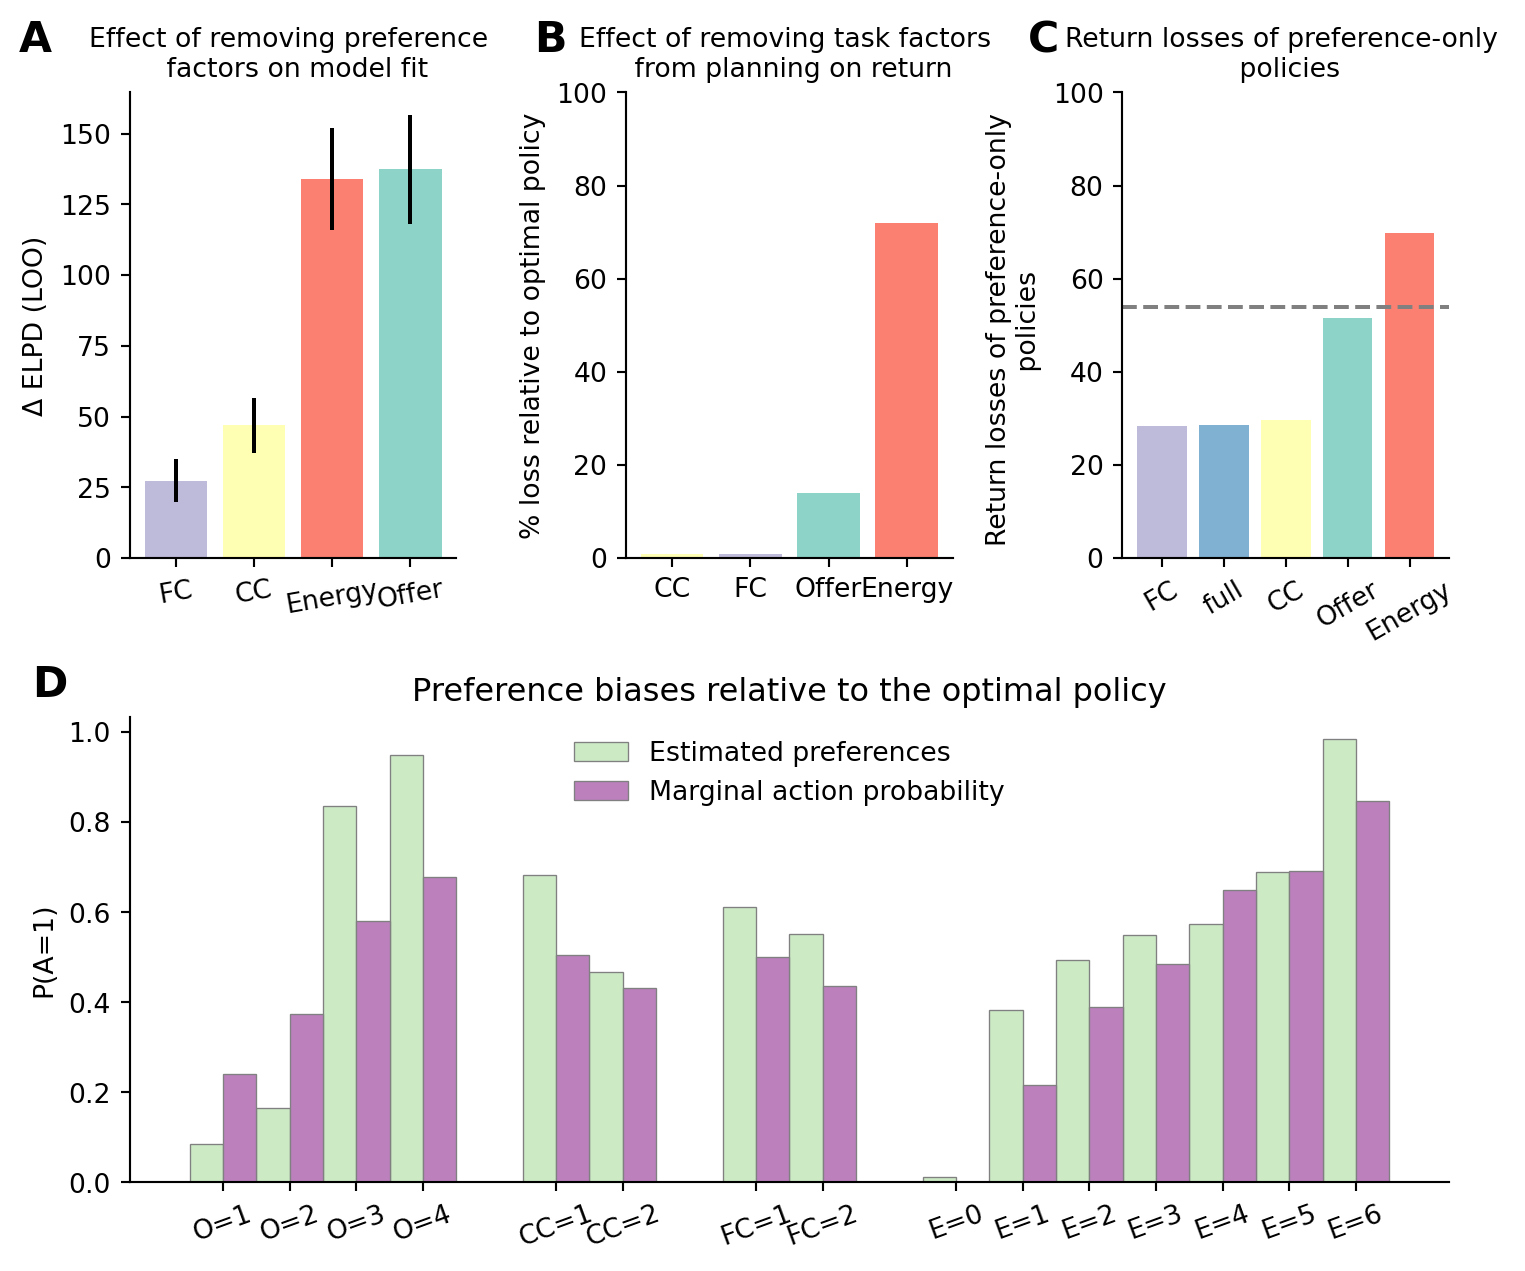

In [22]:
#| label: fig-task-features
#| fig-cap: "Importance of each parameters in participants response and optimal solution. 
#| (A) Difference in fit
#| between the full preference model and models in which each of the experimental factors were removed from preference estimations. 
#| Values closer to 0 indicate that the factor does not lead to a strong improvement of the model fit (i.e. the factor weight less in
#| participants final decision). 
#| (B) Loss in return when planning when ignoring each task factor (0 indicates no loss compared to optimal policy). This figure represents the reward sensitivity
#| of each task factor: the larger the return loss, the more actions are dependent on the levels of the factor for return maximization. For example, the 
#| large loss associated with energy reflects the fact that when all energy levels are treated the same leads to accepting offers when energy is low, leading 
#| to low energy, preventing accepting future returns. 
#| (C) Loss in return of policies derived from the preference component of the full and reduced preference models omitting each task factors.  
#| For each model (full and reduced), we derive a policy from the preference component alone and calculated the expected return under such a policy, relative 
#| to the optimal policy. The y-axis represents the loss in relative return, 0 indicates that a preference policy performs exactly as well as the optimal policy.
#| The grey line represents the return associated with a fully stochastic policy (i.e. equal probability of each action in each state). 
#| (D) Comparison between preference (in probability space) parameters and the marginal action probability of each task level."

fig, ax = plt.subplot_mosaic("ABC;DDD", figsize=[A4_inches[0], 0.6*A4_inches[1]]) 
cmap = matplotlib.colormaps.get_cmap('Set3')
colors = {key: cmap(i) for i, key in enumerate(["Offer", "CC", "FC", "Energy", "full"])}
# ================================================
# fig-2A: model comparison:
# elpd_loo bar plot with error bar
ax["A"].bar(    
    range(len(model_comparison)-1),
    model_comparison.iloc[1:]["elpd_diff"],
    yerr=model_comparison.iloc[1:]["dse"],
    color=[colors[key] for key in model_comparison.index[1:]]
)
# Decoration
ax["A"].set_xticks(range(len(model_comparison)-1))
ax["A"].set_xticklabels(model_comparison.index[1:], rotation=10)
ax["A"].set_ylabel("Δ ELPD (LOO)")
ax["A"].set_title("Effect of removing preference \n factors on model fit", fontsize=10)
ax["A"].spines[['right', 'top']].set_visible(False)


# ================================================
# fig-2B: returns from the reduced MDP:
order = np.argsort([return_reduced[key] for key in return_reduced.keys()])
ax["B"].bar(    
   np.array([key for key in return_reduced.keys()])[order], 
   np.array([return_reduced[key] * 100 for key in return_reduced.keys()])[order],
   color=np.array([colors[key] for key in return_reduced.keys()])[order]
)
# Decoration
# ax["B"].axhline(1-returns_stochastic/returns_optimal, color="grey", linestyle="--")
ax["B"].set_ylabel("% loss relative to optimal policy")
ax["B"].set_title("Effect of removing task factors \n from planning on return", fontsize=10)
ax["B"].spines[['right', 'top']].set_visible(False)
ax["B"].set_ylim([0, 100])

# ================================================
# fig-2C: returns from the preferences only:
order = np.argsort([returns_pref[key] for key in returns_pref.keys()])
ax["C"].bar(   
    np.array([key for key in returns_pref.keys()])[order], 
    np.array([returns_pref[key] * 100 for key in returns_pref.keys()])[order],
    color=np.array([colors[key] for key in returns_pref.keys()])[order]
)
ax["C"].axhline((1-returns_stochastic/returns_optimal) * 100, color="grey", linestyle="--")
# Decoration
ax["C"].set_xticks(range(len(returns_pref)))
ax["C"].set_xticklabels(np.array([key for key in returns_pref.keys()])[order], rotation=30)
ax["C"].set_ylabel("Return losses of preference-only \n policies")
ax["C"].set_ylim([0, 100])
ax["C"].set_title("Return losses of preference-only \n policies", fontsize=10)
ax["C"].spines[['right', 'top']].set_visible(False)


# ================================================
# fig-2D: marginal proba under optimal policy vs preferences
# Extract the preference parameters:
pref_param = traces["Preference"].posterior["beta_pref"].mean(dim=["chain", "draw"]).values
positions = np.array([0, 2, 4, 6, 10, 12, 16, 18, 22, 24, 26, 28, 30, 32, 34])
ax["D"].bar(    
    positions, 
    expit(pref_param), 
    color=cmap(10),
    width=1, 
    label='Estimated preferences',
    edgecolor="grey", linewidth=0.5
)
positions2 = np.array(positions)+1
ax["D"].bar(    
    positions2, 
    marginal_action_proba, 
    color=cmap(9),
    width=1, 
    label="Marginal action probability",
    edgecolor="grey", linewidth=0.5
)
# Decoration
ax["D"].set_xticks(np.mean(np.array([positions, positions2]), axis=0))
[
        'is_1', 'is_2', 'is_3', 'is_4', 
        'is_lc', 'is_hc', 
        'is_lfc', 'is_hfc', 
        'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6'
    ]
ax["D"].set_xticklabels(["O=1", "O=2", "O=3", "O=4", 
                         "CC=1", "CC=2", "FC=1", "FC=2",
                         "E=0", "E=1", "E=2", "E=3", "E=4", "E=5", "E=6"], rotation=20)
ax["D"].set_ylabel("P(A=1)")
ax["D"].set_title("Preference biases relative to the optimal policy")
ax["D"].spines[['right', 'top']].set_visible(False)
ax["D"].legend(frameon=False)
plt.tight_layout()

ax["A"].text(0.04, 0.98, "A", transform=fig.transFigure, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              );
ax["B"].text(0.385, 0.98, "B", transform=fig.transFigure, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
ax["C"].text(0.715, 0.98, "C", transform=fig.transFigure, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
ax["D"].text(0.05, 0.48, "D", transform=fig.transFigure, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              );

We next asked whether the fitted preferences could serve as adaptive biases when planning is absent. As a first step, we quantified how strongly optimal return depends on each task factor. To do so, we derived policies from reduced planning models in which one task factor was ignored, and computed their return loss relative to the optimal policy (@fig-task-features B). Our results show that ignoring current and future costs when planning leads only to minimal losses (`{python} f"{return_reduced["CC"]*100:.2f}"`% and `{python} f"{return_reduced["FC"]*100:.2f}"`% respectively), while ignoring the offer level leads to a `{python} f"{return_reduced["Offer"]*100:.2f}"`% loss. The biggest loss is incurred when ignoring energy levels. This leads to a loss in returns of `{python} f"{return_reduced["Energy"]*100:.2f}"`%, which is even larger than a purely stochastic policy (i.e. equal probability of accepting and rejecting an offer on each trial). This indicates that reward maximization under planning is highly sensitive to energy. This large loss reflects the structure of the task. A policy that ignores energy cannot adapt choices to the current energy budget. As a result, it can deplete energy in low-energy states as its behaviour is driven by offer levels. The large reward sensitivity of energy is not mirrored in @fig-task-features A because that analysis measures the additional predictive contribution of preference terms after accounting for planning-derived decision-values. Energy is already strongly reflected for by the planning component, so removing energy-related preference terms has a smaller effect on model fit than its importance for optimal return would suggest.  

Further, we asked whether the fitted preferences could support adaptive choice when planning is absent. If preferences capture useful task structure, policies derived from the preference component alone should be suboptimal, but should still produce lower return loss than a stochastic policy. In addition, removing task factors that strongly shape participants’ preferences should reduce the return of these preference policies. To quantify this, we computed the expected return loss of policies derived from the preference component alone. The full preference policy produced, as expected, a non-zero return loss of `{python} f"{returns_pref["full"]*100:.2f}"`%, indicating that preferences did not fully replace planning, see @fig-task-features C. However, this loss was smaller than the loss of a stochastic policy (grey line), showing that the fitted preferences captured task structure that was useful for return maximization (@fig-task-features C). Removing current or future cost from the preference policy produced little additional loss relative to the full preference policy (`{python} f"{returns_pref["CC"]*100:.2f}"` and `{python} f"{returns_pref["FC"]*100:.2f}"`% respectively). In contrast, removing offer value led to a substantial loss in return of `{python} f"{returns_pref["Offer"]*100:.2f}"`%. The largest loss occurred when energy was removed (`{python} f"{returns_pref["Energy"]*100:.2f}"`% loss), with performance falling below that of the stochastic policy. This suggests that an energy-blind preference policy is not merely less informative, but can become systematically maladaptive by accepting attractive offers without regard to the current energy budget. 

Together, these results suggest that participants’ preferences were not arbitrary biases, but adaptive approximations to optimal choice. They supported relatively good performance in the absence of planning, while remaining insufficient to fully replace planning-derived decision values. 

How do participants derive such adaptive preferences? A potential explanation is that participants have access to some approximation of the marginal action probability associated with each factor of the task under the optimal policy (of how often should an offer of 1 be accepted, across all energy and costs levels for example). To explore whether this might be contributing to an underlying mechanism for learning participants’ preferences, we computed the factor-dependent marginal action probability under the optimal policy. @fig-task-features D plots the preferences parameters side-by-side with the marginal action probability, showing that participants’ preferences relatively closely reflect the feature specific marginal action probability of the optimal policy, with some notable deviations. For offer levels 1 and 2, preferences are lower than marginal action probability, and higher when for offer levels 3 and 4. Across all other tasks levels, participants preferences are larger than marginal action probability (except for energy=4), suggestive of an optimistic bias (i.e. tendency to accept offers more often than they should). Nonetheless, the overall similarities between both variables suggest that this is a plausible explanation of participants preferences.

### Reaction times
Under the proposed hypothesis, participants’ reliance on planning should depend on the strength of their preferences. Strong preferences should reduce the need for planning and therefore lead to faster responses, whereas weak or uncertain preferences should increase reliance on planning and lead to slower responses. Previous studies have shown that RT is positively correlated with planning conflict, indicating that less planning is required when the value associated with each action is more clearly distinct [@ott2022forward]. We therefore expected preference strength to attenuate the effect of planning conflict on RT: when participants’ preferences provide a clear action tendency, conflict between planning-derived action values should have a weaker influence on response times. 

In [23]:
#| include: false
beh_data['logRT'] = np.log(beh_data['reaction_time'])

# Repeat Ott's RT model:
beh_data['conflict'] = -np.abs(beh_data['dv'])
beh_data['intermediate'] = beh_data['is_2'] + beh_data['is_3']
beh_data['entropy'] = np.mean(traces['Preference'].posterior["entropy"], axis=(0, 1))

traces_RT = {}

# ===================================================================
# Conflict entropy interaction model:
interaction_rt_model = bmb.Model(
    "logRT ~ conflict + entropy + conflict:entropy +"
    "(conflict + entropy|vpn)", 
    beh_data
    )
traces_RT['RT = Conflict x H(Pref)'] = interaction_rt_model.fit(
    draws=1000, target_accept=0.95, idata_kwargs={"log_likelihood": True},
)

# ===================================================================
# Conflict entropy model without interaction:
# pref_conflict_rt_model = bmb.Model(
#     "logRT ~ conflict + entropy +"
#    "(conflict + entropy|vpn)", 
#    beh_data
#    )
#traces_RT['RT = Conflict + H(Pref)'] = pref_conflict_rt_model.fit(
#    draws=1000, target_accept=0.95, idata_kwargs={"log_likelihood": True},
#)

# ===================================================================
# Conflict entropy interaction model:
#conflict_rt_model = bmb.Model(
#    "logRT ~ conflict +"
#    "(conflict|vpn)", 
#    beh_data
#    )
#traces_RT['RT = Conflict'] = conflict_rt_model.fit(
#    draws=1000, target_accept=0.95, idata_kwargs={"log_likelihood": True},
#)

# Compare the models:
#rt_model_comparison = az.compare(traces_RT)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, conflict, entropy, conflict:entropy, 1|vpn_sigma, 1|vpn_offset, conflict|vpn_sigma, conflict|vpn_offset, entropy|vpn_sigma, entropy|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 59 seconds.


In [24]:
# Extract mean and CI of the fitted parameters:
mu_conflict = traces_RT['RT = Conflict x H(Pref)'].posterior["conflict"].values.flatten().mean()
ci_conflict = az.hdi(traces_RT['RT = Conflict x H(Pref)'].posterior["conflict"].values)[0]

mu_pref = traces_RT['RT = Conflict x H(Pref)'].posterior["entropy"].values.flatten().mean()
ci_pref = az.hdi(traces_RT['RT = Conflict x H(Pref)'].posterior["entropy"].values)[0]

mu_interaction = traces_RT['RT = Conflict x H(Pref)'].posterior["conflict:entropy"].values.flatten().mean()
ci_interaction = az.hdi(traces_RT['RT = Conflict x H(Pref)'].posterior["conflict:entropy"].values)[0]

Indeed, we found that participants’ RT was influenced by (i) conflict ($\beta_{conflict}$=`{python} f"{mu_conflict:.2f}"`, CI=[`{python} f"{ci_conflict[0]:.2f}, {ci_conflict[1]:.2f}"`]), (ii) entropy of preferences ($\beta_{pref}$=`{python} f"{mu_pref:.2f}"`, CI=[`{python} f"{ci_pref[0]:.2f}, {ci_pref[1]:.2f}"`]) and (iii) the interaction between the two ($\beta_{modulation}$=`{python} f"{mu_interaction:.2f}"`, CI=[`{python} f"{ci_pref[0]:.2f}, {ci_pref[1]:.2f}"`], see @fig-rt A). This result extends on previous findings showing that participants do not rely on planning to the same extent across all states of the task. Our results suggest that rather than splitting the task in independent contexts and engaging in planning to a different extent across those [@ott2022forward], the differential amount of planning across states instead reflects the interaction between strength of preferences and conflict. The positive interaction (see @fig-rt A) between conflict and entropy of preferences indicates that the reliance on planning is modulated by the strength of participants’ preferences. Specifically, as can be seen in @fig-rt B, planning depends less on conflict when preferences are strong (blue line), but more so when preferences are weaker (orange and green lines).

In other words, when preferences are strong and prescribe a clear action tendency, participants do not engage much effort in planning, even if conflict between decision values is high. Participants rely most on planning when preferences are weak. The highest RTs are observed when preferences are weak (green line) and conflict is high.  

Together, these results converge with the choice model and show that participants relied more strongly on planning-derived values when their task-structured preferences were weak, and this increased reliance was reflected in slower responses under planning conflict. Conversely, strong preferences were associated with weaker effects of planning conflict and faster choices.

Default computed for unspecified variable: vpn


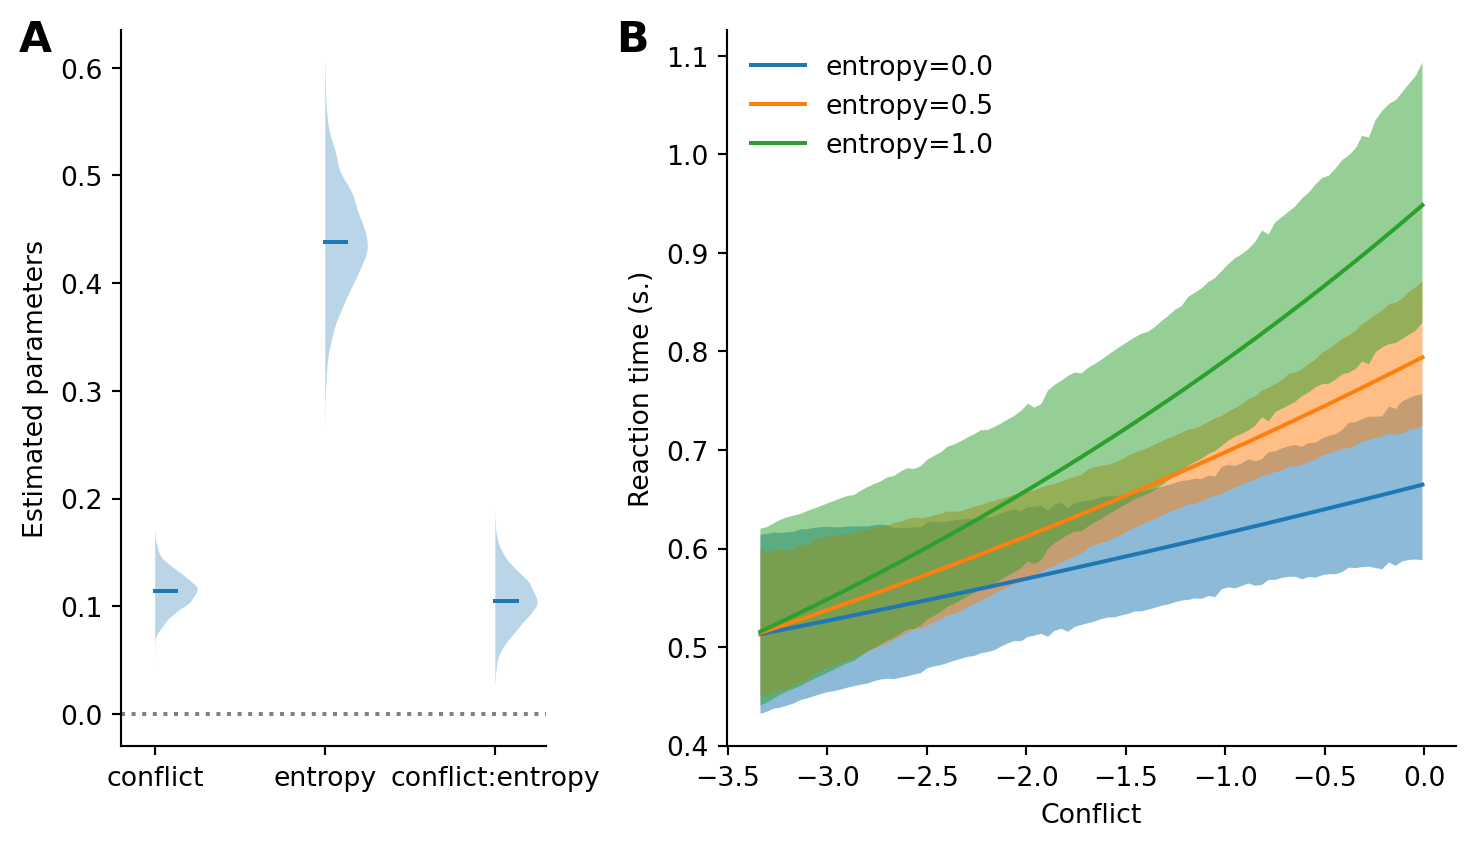

In [25]:
#| label: fig-rt
#| fig-cap: "Results of reaction time models. (A) Comparison of the model of RT as a function of decision values and intermediate offer against the model of RT
#| as a function of decision values and preferences. (B) Posterior distribution of the fitted parameter. (C) Posterior predictive curve depicting the predicted
#| reaction time as a function of the conflict values, separately for preference entropy of 0, 0.5 and 1.0"
fig, ax = plt.subplot_mosaic("AABBB", figsize=[A4_inches[0], 0.4*A4_inches[1]])#, gridspec_kw=dict(width_ratios=[0.5, 1]))
# ================================================
# fig-2A: model comparison:
# elpd_loo bar plot with error bar
#ax["A"].bar(    
#    list(traces_RT.keys()),
#    rt_model_comparison["elpd_loo"],
#    yerr=rt_model_comparison["se"],
#    color=cmap([1, 2])
#)
# Decoration
#ax["A"].set_xticklabels(ax["A"].get_xticklabels(), 
#                        rotation=15, ha='right')
#ax["A"].set_ylabel("ELPD (LOO)")
#ax["A"].set_ylim([-6750, -5000])
#ax["A"].set_title("Model comparison")
#ax["A"].spines[['right', 'top']].set_visible(False)
#ax["A"].text(-0.1, 1.05, "A", transform=ax["A"].transAxes, 
#              fontsize=16, fontweight='bold', va='top', ha='right'
#              )

# ================================================
# fig-B: Plot the preferences parameters of the preference & conflict model:
# Create new axes
params = [
    "conflict", "entropy", "conflict:entropy"
]
x_labels = ["conflict", "entropy", "conflict:entropy"]

ax["A"].set_ylabel("Estimated parameters")
data = []
for var in params:
    vals = traces_RT['RT = Conflict x H(Pref)'].posterior[var].values.flatten()
    data.append(vals)
ax["A"].violinplot(data, positions=range(len(params)), 
                    showmeans=False,
                    showmedians=True,
                    showextrema=False,
                    side="high");
ax["A"].set_xticks(range(len(params)))
ax["A"].set_xticklabels(x_labels)
ax["A"].spines[['right', 'top']].set_visible(False)
ax["A"].hlines(0, -0.2, 2.3, color='gray', linestyles=':')
ax["A"].set_xlim([-0.2, 2.3])

# ================================================
# fig-C: Plot the preferences parameters of the preference & conflict model:
pred_df = bmb.interpret.predictions(
    interaction_rt_model,
    traces_RT['RT = Conflict x H(Pref)'],
    conditional={
        "conflict": np.linspace(beh_data['conflict'].min(), beh_data['conflict'].max(), 100),
        "entropy": [0, 0.5, 1]
    },
)
pred_df["RT"] = np.exp(pred_df["estimate"])
pred_df["RT_low"] = np.exp(pred_df["lower_3.0%"])
pred_df["RT_up"] = np.exp(pred_df["upper_97.0%"])

for ent in pred_df["entropy"].unique():
    subset = pred_df[pred_df["entropy"] == ent]
    ax["B"].plot(subset["conflict"], subset["RT"], label=f"entropy={ent}")
    ax["B"].fill_between(subset["conflict"], subset["RT_low"], subset["RT_up"], alpha=0.5)
ax["B"].spines[['right', 'top']].set_visible(False)
ax["B"].set_xlabel('Conflict')
ax["B"].set_ylabel('Reaction time (s.)')
ax["B"].legend(frameon=False, loc="upper left")
plt.tight_layout()
ax["A"].text(0.04, 0.98, "A", transform=fig.transFigure, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
ax["B"].text(0.44, 0.98, "B", transform=fig.transFigure, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              );

## Discussion
In this paper, we tested the hypothesis that deviations from optimal forward planning in complex sequential decision making reflect structured preference-based guidance rather than unsystematic errors or simple history- and context-dependent biases. Across choice models, participants’ decisions were best explained by a model that combined planning-derived decision values with task-structured preferences over offers, energy, and costs. Critically, the influence of planning depended on the strength of these preferences: planning-derived values shaped choices more strongly when preferences were uncertain. Similarly, response-time analyses showed stronger effects of planning conflict when preferences were uncertain. Additional policy analyses indicated that these preferences were adaptive in the sense that they preserved reward-relevant task structure and supported above-stochastic returns even without planning. Policies relying solely on preferences achieved substantially higher returns than stochastic choice, although they remained below the optimal policy based on planning. Feature-wise analyses showed that these preferences captured reward-relevant structures of the task. Together, these results suggest that participants used task-structured preferences as efficient approximations to optimal choice, while relying more strongly on forward planning when these preferences did not provide a clear action tendency. 

Our hypothesis was motivated by Bayesian accounts of perception and sensorimotor control, in which current evidence is integrated with prior information according to their relative uncertainty. The present findings are consistent with this general principle, but they do not establish that the fitted preferences are priors in a formal Bayesian sense. Rather, they suggest that task-structured preferences can function like prior action tendencies. Preferences provided efficient guidance when they were strong, whereas planning-derived values had a stronger influence on both choices and response times when preferences were weak or uncertain. Future work could test this analogy more directly by manipulating the reliability of preference-based and planning-based information, or by specifying process models in which preferences enter explicitly as action priors. 

The term preferences should therefore not be understood as referring to arbitrary biases that are simply added to an otherwise planning-based decision. In the present account, preferences are structured action tendencies derived from task features, and they shape behaviour by determining how strongly planning-derived values influence choice. An intuitive interpretation is that these preferences provide an efficient, state-dependent default policy that can support above-stochastic performance even in the absence of planning. In some task states, the relevant features jointly imply a clear action tendency. For example, a high offer combined with low current cost and high energy strongly favours accepting (see estimated parameters in @fig-choicemdl D), so little additional forward planning may be required. In other states, different features support opposing actions. For instance, a moderate offer may favour rejection, whereas low cost and high energy may favour acceptance, resulting in a weaker and more uncertain preference signal. In such cases, forward planning can help resolve the remaining ambiguity by evaluating the future consequences of the available actions. Thus, preferences may act as an inexpensive and quickly available first-pass guide that is often sufficient to support above-stochastic returns, but is complemented by planning when preferences are uncertain and planning-derived action values are in conflict. 

A methodological contribution of the present study is that we combined a planning-derived decision-value term with a factorized preference component defined over the task features. Computational models of sequential decision making often include additional parameters capturing response biases, perseveration, or other deviations from value-based choice [@ott2022forward;@ott2020dynamic;@huys2012bonsai;@ho2022people;@schwartenbeck2015dopaminergic]. However, these terms are typically low-dimensional and are not usually decomposed according to the experimental structure of the task. Conversely, factorial analyses of experimental data can quantify how different task factors influence behaviour or neural responses [@barr2013random;@baayen2010analyzing;@ashburner2014spm12;@singmann2019introduction], but they do not by themselves specify how these effects relate to forward planning. By combining these approaches, our model treats task-factor effects not as residual noise around planning, but as structured action tendencies that can guide choices and modulate reliance on planning-derived values. This approach may be particularly useful in complex sequential decision-making tasks, where choices depend on several distinct task dimensions. In the present task, offer value, energy, current cost, and future cost each provided potential bases for preference-based guidance. Such structured dimensions are less obvious in simpler two-alternative value-based choice tasks, where it may be harder to identify feature-specific preference components. 

Our results also reframe how deviations from optimal planning should be interpreted. Across psychology and perceptual decision making, deviations from normative models have often been described as biases or heuristics [@tversky1974judgment;@gilovich2002heuristics] (Tversky and Kahneman, 1974; Gilovich and Griffin, 2002; Rahnev and Denison, 2018; Berthet and de Gardelle, 2023). Such deviations can lead to systematic errors, but they may also reflect efficient approximations that reduce computational demands. The present findings support this latter interpretation in the context of sequential decision making. Participants’ preferences were not arbitrary residuals around an optimal planning process. Instead, they captured task structure, supported above-stochastic returns when used without planning, and modulated the influence of planning-derived values. Thus, deviations from optimal planning may in part reflect structured approximations that guide behaviour when full state-specific evaluation is costly, uncertain, or unnecessary. This interpretation does not require a strict separation between a fast heuristic system and a slow planning system. Rather, in the Bayesian analogy developed here, task-structured preferences play the role of action priors, whereas planning-derived values provide the likelihood-like, state-specific evidence about which action will lead to better future outcomes. The results therefore suggest a single decision process in which action priors and planning-derived evidence are integrated according to their relative uncertainty. 

The preference component of our model is descriptive, and the present analyses therefore cannot determine how these preferences were formed. Several non-exclusive sources are possible. First, participants may have learned task-structured preferences during the extensive training phase, during which they experienced how offers, energy, and costs affected reward. Second, some preferences may reflect more general schemas about resource allocation. For example, many everyday decisions involve taking valuable opportunities when they are cheap and resources are sufficient, but declining less valuable opportunities when resources are scarce. Third, participants may have inferred simple preference rules directly from the task instructions, which explicitly described the relevant dimensions of the task. These possibilities differ in whether preferences arise from task experience, prior experience, or instructed structure, but they share the idea that preferences may reflect compressed representations of the task that guide choice before full forward evaluation is required. Future work could distinguish these sources by manipulating training, instructions, and the familiarity of the task structure. 

This framing of preferences as priors also connects our results to work suggesting that deviations from optimal behaviour are not necessarily errors, but can be instrumental when processes associated with decision making (ranging from perceptual to motor responses) are noisy or when processing resources are limited [@summerfield2018perceptual;@tsetsos2016economic;@schwiedrzik2014untangling;@fischer2014serial]. Recent efforts to apply rate distortion theory to decision making and the policy compression framework have shown that biases towards most frequent actions can be instrumental: for an agent under resource constraints, efficient choice can involve integrating planning with compressed action tendencies, such as the marginal action distribution under the optimal policy which can be interpreted as a prior over actions [@tishby2010information;@still2012information;@lai2024human;@lai2021policy]. Our present study extends this idea by showing that rather than integrating planning with state independent priors over actions, participants rely on state-dependent preferences. This is an important addition to the policy compression framework, which to our knowledge has primarily been tested in tasks with small state spaces or where current actions have limited downstream consequences [@lai2024human;@bari2023undermatching;@liu2025action;@lai2022action;@gershman2025policy]. In more complex tasks, where many states can require different actions and where action–state combinations have downstream implications, state independent choice history biases may not provide a sufficiently structured alternative to planning when computational resources are limited. It is therefore likely that to solve real world, complex problems, humans rely on structured priors that reflect relevant dimensions of the environment, enabling them to make good decisions when planning-derived values are uncertain or costly to compute. 

The use of an exact dynamic-programming algorithm (backward induction) to derive action values for the planning component of our model does not imply that this is how planning has to be implemented in the brain. It is more likely that biologically plausible planning algorithms rely on approximate computations, such as sampling methods, partial tree search and approximate value computations [@sutton1998reinforcement;@silver2016mastering ADD MORE REFERENCES]. We are not committed to any one of these alternatives, as our main interest in the paper was to investigate the structure underlying participants’ deviations from planning. The observation that RT depends on the interaction between preferences strength and decision conflict suggests that whichever algorithm implements action value estimation in the brain, the extent of planning-related computation can be adaptively adjusted to obtain more or less precise estimates depending on the specific circumstances in which planning is required. 

The account also makes testable predictions about when preference-based guidance should dominate. Reliance on preferences should increase when task features provide a clear action tendency, when planning time is limited, or when the marginal value of additional computation is low. Conversely, reliance on planning should increase when task features provide conflicting action tendencies, when future consequences are difficult to infer from local features alone, or when the cost of an error is high. Future experiments could test these predictions by manipulating time pressure, planning horizon, task volatility, or the reliability of feature-based cues. 

ADD SECTION DISCUSSING FUTURE DIRECTION: 

Investigating dynamism of preferences (not really necessary, but we could add something to the learning preferences paragraph, adding that we assume that preferences are static but this is just the method of estimation, while we assume for our task they have converged after training. But clearly, learning may be ongoing so even with the same task, preferences may be dynamic/adaptive.  

Try to incorporate structure dependent priors to existing Bayesian models of decision making (I wouldn’t add this, it’s future work, and we should only discuss what we found in the paper).  

... 

## Acknowledgements

## Data and code statement
All data used in this paper were previously published as part of @ott2022forward, and are available at https://zenodo.org/records/6328296. Code can be found on github https://github.com/AlexLepauvre/state_abstraction_paper. In addition, we've created a custom toolbox to implement reinforcement learning algorithm, which can be found here: https://github.com/AlexLepauvre/state-abstraction

## References

:::{#refs}

:::

## Supplementary material

### Supplementary figures:
{{< embed S1-supplementary_figures_tables.ipynb#suppfig-pref-planning-interaction >}}

### Supplementary tables:
{{< embed S1-supplementary_figures_tables.ipynb#supptbl-model_comparison >}}
{{< embed S1-supplementary_figures_tables.ipynb#supptbl-pref_model_param >}}

### Supplementary model comparison

#### Preferences model comparison:
The preference model was observed to fit the data best, showing that participants behaviour reflects the integration of a planning component together with priors reflecting the structure of the task, shedding light on the structure of the priors themselves. To further show that participants priors reflect the whole structure of the task, we modelled the data removing one experimental factor from the preferences fitting one at a time and compared to the full model, to show that our results cannot be explained by the fact that participants's priors do not reflect a single nor a subset of experimental factors. To further show that participants reliance on planning is modulated by the strength of their preferenecs, a model without the interaction was fitted to highlight the increase in fit associated with the interaction. Finally, to show that participants response is best explained by a combination of planning and preference component, we also fitted a model with only the preference component omitting the planning regressor. 
{{< embed S2-choice_model_comparison.ipynb#suppfig-preference_model_comparison >}}
{{< embed S2-choice_model_comparison.ipynb#supptbl-preferences_model_comparison >}}

#### Frequency model comparison:
In the main text, we compared the preference model with a model in which priors are computed based on action frequency. In this model, the priors are computed using a linearly decaying moving average, discounting actions that occured further in the past. We presented the results obtained when the priors are derived from the 20 previous trials. This number of trials was selected by exploring priors witk $k=[2, 5, 10, 15, 20, 30, 50]$ to identify the values that fit the data the best:
{{< embed S2-choice_model_comparison.ipynb#suppfig-frequency_model_comparison >}}
{{< embed S2-choice_model_comparison.ipynb#supptbl-frequency_model_comparison >}}

### Parameters recovery:
In the main text, the preference model was observed to fit participants behaviour the best, supporting the hypothesis that participants decision reflects the integration of forward planning with state dependent preferences. The preferences model is rather complex, with preference parameters being estimated as latent variable, and entailing an additional entropy transformation in the interaction term. To establish that despite the complexity of the model, it is still capable of accurately estimate all parameters, we perform a parameter recovery analysis in which we simulate data using the mean parameters recovered from the original data. We then fit the same model to the simulated data. We can then compare the estimated parameters from the simulated data against ground truth to establish the model capacity to identify parameters correctly. 

{{< embed S3-parameters_recovery.ipynb#suppfig-population_parameter_recovery >}}
{{< embed S3-parameters_recovery.ipynb#suppfig-single_subject_parameter_recovery >}}

Across all participants, the ground truth parameters is well within the credible intervals of the retrieved parameters from the data, indicating that our model is indeed capable of recovering the parameters of the underlying generative model.